# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [1]:
# Python setup
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.metrics import confusion_matrix

pd.set_option('display.max_columns', None)


In [2]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)
raw_data.shape[0]

7214

In [3]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.0,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.0,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.0,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.0,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,0,1,0,0,0,0.0,2013-11-30 04:50:18,2013-12-01 12:28:56,13022355MM10A,2013-11-30,NaN,0.0,M,Battery,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-11-30,Risk of Violence,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,0,6,0,0,14,-1.0,2014-02-18 05:08:24,2014-02-24 12:18:30,14002304CF10A,2014-02-18,NaN,1.0,F,Possession Burglary Tools,1,14004485CF10A,(F2),0.0,2014-03-31,Poss of Firearm by Convic Felo,2014-03-31,2014-04-18,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,6,Medium,2014-02-19,Risk of Violence,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,0,4,0,0,3,-1.0,2013-08-29 08:55:23,2013-08-30 08:42:13,13012216CF10A,NaN,2013-08-29,1.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-08-30,Risk of Violence,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,0,1,0,0,0,-1.0,2014-03-15 05:35:34,2014-03-18 04:28:46,14004524MM10A,2014-03-15,NaN,1.0,M,Battery,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2014-03-16,Risk of Violence,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less

However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [4]:
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

df = raw_data[
    [
        "age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
        "priors_count", "days_b_screening_arrest", "decile_score",
        "is_recid", "two_year_recid", "c_jail_in", "c_jail_out"
    ]
].copy()

# Filtering
df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

# Type conversions
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)

for col in df.columns:
    if col not in numeric_vars + datetime_vars:
        df[col] = df[col].astype("category")

# Derived factors with reference levels
df["crime_factor"] = df["c_charge_degree"].astype("category")

age_order = ["25 - 45", "Greater than 45", "Less than 25"]
df["age_factor"] = pd.Categorical(df["age_cat"], categories=age_order, ordered=False)

race_levels = ["Caucasian"] + [x for x in df["race"].cat.categories if x != "Caucasian"]
df["race_factor"] = pd.Categorical(df["race"], categories=race_levels, ordered=False)

df["gender_factor"] = pd.Categorical(df["sex"], categories=["Male", "Female"], ordered=False)

df["score_factor"] = np.where(df["score_text"] != "Low", "HighScore", "LowScore")
df["score_factor"] = pd.Categorical(df["score_factor"], categories=["LowScore", "HighScore"], ordered=False)

df.shape[0]

6172

In [5]:
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [7]:
df["c_jail_in"] = pd.to_datetime(df["c_jail_in"])
df["c_jail_out"] = pd.to_datetime(df["c_jail_out"])

df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days
df["length_of_stay"].corr(df["decile_score"])


np.float64(0.20747808478031807)

After filtering we have the following demographic breakdown:

In [8]:
df["age_cat"].value_counts()

,count
age_cat,
25 - 45,3532
Less than 25,1347
Greater than 45,1293


In [9]:
df["race"].value_counts()

,count
race,
African-American,3175
Caucasian,2103
Hispanic,509
Other,343
Asian,31
Native American,11


In [10]:
print("Black defendants: %.2f%%" % (3175 / 6172 * 100))
print("White defendants: %.2f%%" % (2103 / 6172 * 100))
print("Hispanic defendants: %.2f%%" % (509  / 6172 * 100))
print("Asian defendants: %.2f%%" % (31   / 6172 * 100))
print("Native American defendants: %.2f%%" % (11   / 6172 * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [11]:
df["score_text"].value_counts()

,count
score_text,
Low,3421
Medium,1607
High,1144


In [12]:
pd.crosstab(df["sex"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [13]:
df["sex"].value_counts()

,count
sex,
Male,4997
Female,1175


In [14]:
print("Men: %.2f%%" % (4997 / 6172 * 100))
print("Women: %.2f%%" % (1175 / 6172 * 100))

Men: 80.96%
Women: 19.04%


In [15]:
df[df["two_year_recid"] == 1].shape[0]

2809

In [16]:
df[df["two_year_recid"] == 1].shape[0] / df.shape[0] * 100

45.51198963058976

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

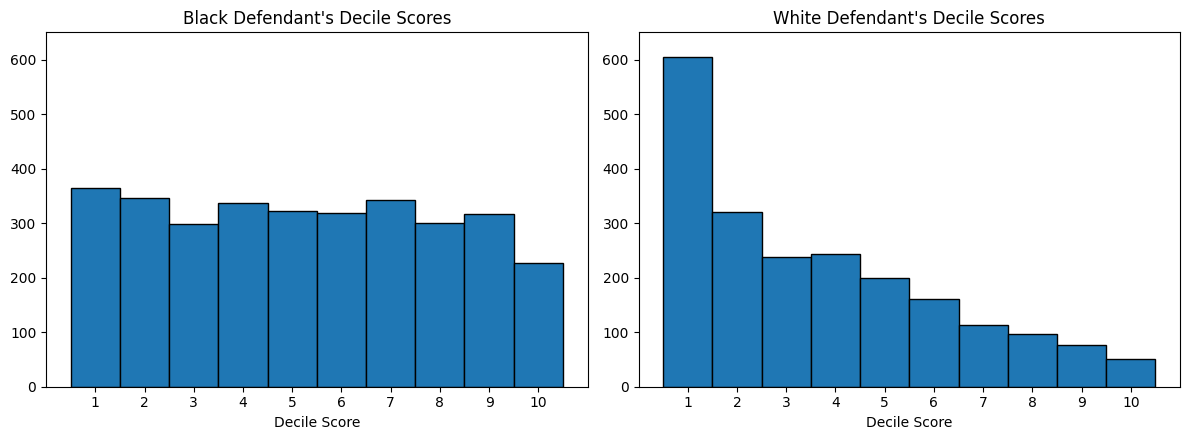

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

black_scores = df.loc[df["race"] == "African-American", "decile_score"]
white_scores = df.loc[df["race"] == "Caucasian", "decile_score"]

axes[0].hist(black_scores, bins=np.arange(0.5, 11.5, 1), edgecolor="black")
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylim(0, 650)
axes[0].set_xticks(range(1, 11))

axes[1].hist(white_scores, bins=np.arange(0.5, 11.5, 1), edgecolor="black")
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylim(0, 650)
axes[1].set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

In [18]:
pd.crosstab(df["decile_score"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into categorical variables, and run a logistic regression, comparing low scores to high scores.

In [19]:
df["score_binary"] = (df["score_factor"] == "HighScore").astype(int)

model_glm = smf.logit(
    "score_binary ~ "
    "C(gender_factor, Treatment(reference=\"Male\")) + "
    "C(age_factor, Treatment(reference=\"25 - 45\")) + "
    "C(race_factor, Treatment(reference=\"Caucasian\")) + "
    "priors_count + "
    "C(crime_factor) + "
    "two_year_recid",
    data=df
).fit(disp=False)

model_glm.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Tue, 28 Apr 2026   Pseudo R-squ.:                  0.2729
Time:                        21:44:38   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
========================================================================================================================================
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                               -1.5255      0.079    -19.430      0.000      -1.679      -1.372
C(gender_factor, Treatment(reference="Male"))[T.Female]                  0.2213      0.080      2.783      0.005       0.065       0.377
C(age_factor, Treatment(reference="25 - 45"))[T.Greater than 45]        -1.3556      0.099    -13.682      0.000      -1.550      -1.161
C(age_factor, Treatment(reference="25 - 45"))[T.Less than 25]            1.3084      0.076     17.232      0.000       1.160       1.457
C(race_factor, Treatment(reference="Caucasian"))[T.African-American]     0.4772      0.069      6.881      0.000       0.341       0.613
C(race_factor, Treatment(reference="Caucasian"))[T.Asian]               -0.2544      0.478     -0.532      0.595      -1.192       0.683
C(race_factor, Treatment(reference="Caucasian"))[T.Hispanic]            -0.4284      0.128     -3.344      0.001      -0.680      -0.177
C(race_factor, Treatment(reference="Caucasian"))[T.Native American]      1.3942      0.766      1.820      0.069      -0.107       2.896
C(race_factor, Treatment(reference="Caucasian"))[T.Other]               -0.8263      0.162     -5.098      0.000      -1.144      -0.509
C(crime_factor)[T.M]                                                    -0.3112      0.067     -4.677      0.000      -0.442      -0.181
two_year_recid[T.1]                                                      0.6859      0.064     10.713      0.000       0.560       0.811
priors_count                                                             0.2689      0.011     24.221      0.000       0.247       0.291
========================================================================================================================================
"""

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [20]:
control = np.exp(-1.52554) / (1 + np.exp(-1.52554))
np.exp(0.47721) / (1 - control + (control * np.exp(0.47721)))

np.float64(1.4528408658138932)

Women are 19.4% more likely than men to get a higher score.

In [21]:
np.exp(0.22127) / (1 - control + (control * np.exp(0.22127)))

np.float64(1.1947978508506671)

Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [22]:
np.exp(1.30839) / (1 - control + (control * np.exp(1.30839)))

np.float64(2.4961202077189455)

In [23]:
df["pred_prob"] = model_glm.predict(df)
df["pred_class"] = np.where(df["pred_prob"] >= 0.5, "Recid", "No Recid")
df["pred_class"] = pd.Categorical(df["pred_class"], categories=["No Recid", "Recid"])

In [24]:
print("\n── Overall Confusion Matrix ──────────────────────────────────────────\n")

overall_cm = pd.crosstab(df["pred_class"], df["two_year_recid"])
print(overall_cm)

TP = overall_cm.loc["Recid", 1]
TN = overall_cm.loc["No Recid", 0]
FP = overall_cm.loc["Recid", 0]
FN = overall_cm.loc["No Recid", 1]
n = overall_cm.to_numpy().sum()

print("\nAccuracy  : %.3f" % ((TP + TN) / n))
print("Precision : %.3f" % (TP / (TP + FP)))
print("Recall    : %.3f" % (TP / (TP + FN)))
print("FPR       : %.3f" % (FP / (FP + TN)))
print("FNR       : %.3f" % (FN / (FN + TP)))


── Overall Confusion Matrix ──────────────────────────────────────────

two_year_recid     0     1
pred_class                
No Recid        2653   945
Recid            710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [25]:
print("\n\n── Confusion Matrix by Race ──────────────────────────────────────────\n")

temp = df.copy()
temp["actual"] = temp["two_year_recid"].astype(int)
temp["pred"] = (temp["pred_class"] == "Recid").astype(int)

race_metrics = temp.groupby("race").apply(
    lambda g: pd.Series({
        "n": len(g),
        "TP": ((g["pred"] == 1) & (g["actual"] == 1)).sum(),
        "TN": ((g["pred"] == 0) & (g["actual"] == 0)).sum(),
        "FP": ((g["pred"] == 1) & (g["actual"] == 0)).sum(),
        "FN": ((g["pred"] == 0) & (g["actual"] == 1)).sum(),
    })
).reset_index()

race_metrics["Accuracy"] = ((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"]).round(3)
race_metrics["Precision"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"])).round(3)
race_metrics["Recall"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"])).round(3)
race_metrics["FPR"] = (race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])).round(3)
race_metrics["FNR"] = (race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])).round(3)

race_metrics = race_metrics.sort_values("n", ascending=False).reset_index(drop=True)
print(race_metrics)



── Confusion Matrix by Race ──────────────────────────────────────────

               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
1         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
2          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
3             Other   343    22   216    3  102     0.694      0.880   0.177   
4             Asian    31     2    22    1    6     0.774      0.667   0.250   
5   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
1  0.104  0.536  
2  0.044  0.571  
3  0.014  0.823  
4  0.043  0.750  
5  0.667  0.000  


In [26]:
print("\n\n── FPR and FNR Disparity by Race ─────────────────────────────────────\n")

disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()
white_fpr = disparity.loc[disparity["race"] == "Caucasian", "FPR"].iloc[0]
white_fnr = disparity.loc[disparity["race"] == "Caucasian", "FNR"].iloc[0]

disparity["delta_FPR"] = (disparity["FPR"] - white_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - white_fnr).round(3)

print(disparity)



── FPR and FNR Disparity by Race ─────────────────────────────────────

               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
1         Caucasian  2103  0.104  0.536      0.000      0.000
2          Hispanic   509  0.044  0.571     -0.060      0.035
3             Other   343  0.014  0.823     -0.090      0.287
4             Asian    31  0.043  0.750     -0.061      0.214
5   Native American    11  0.667  0.000      0.563     -0.536


In [27]:
from sklearn.model_selection import train_test_split

# Define features and target based on previous analysis (e.g., model_glm)
features = [
    "gender_factor", "age_factor", "race_factor",
    "priors_count", "crime_factor", "two_year_recid"
]
target = "score_binary"

# X and y from the cleaned COMPAS cohort (Lecture 01)
X = df[features]
y = df[target].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 6), Test: (1235, 6)


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Define numeric and categorical features based on the X DataFrame structure
numeric_features = ['priors_count']
category_features = ['gender_factor', 'age_factor', 'race_factor', 'crime_factor', 'two_year_recid']

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), category_features),
])

# Logistic regression (GLM -- interpretable by design)
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipeline.fit(X_train, y_train)

# Gradient-boosted tree (black-box)
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    ))
])
gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['priors_count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender_factor',
                                                   'age_factor', 'race_factor',
                                                   'crime_factor',
                                                   'two_year_recid'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

In [29]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)

def group_metrics(pipeline, X, y, group_col="race"):
    results = []
    X_ = X.copy()
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    for group, gdf in X_.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(
            gdf["actual"], gdf["pred"]
        ).ravel()
        results.append({
            "race" : group,
            "n" : len(gdf),
            "accuracy" : round(accuracy_score(
                gdf["actual"], gdf["pred"]), 3),
            "FPR" : round(fp / (fp + tn), 3),
            "FNR" : round(fn / (fn + tp), 3),
            "AUC" : round(roc_auc_score(
                gdf["actual"],
                gdf["pred_prob"]), 3),
        })
    return pd.DataFrame(results).sort_values("n", ascending=False)

print(" Logistic Regression ")
print(group_metrics(lr_pipeline, X_test, y_test, group_col="race_factor"))
print("\n Gradient-Boosted Tree ")
print(group_metrics(gbt_pipeline, X_test, y_test, group_col="race_factor"))

 Logistic Regression 
               race    n  accuracy    FPR    FNR    AUC
1  African-American  634     0.737  0.387  0.177  0.820
0         Caucasian  412     0.750  0.109  0.562  0.794
3          Hispanic  108     0.824  0.063  0.483  0.831
5             Other   71     0.803  0.019  0.765  0.852
2             Asian    8     0.750  0.000  1.000  0.667
4   Native American    2     0.500  1.000  0.000  1.000

 Gradient-Boosted Tree 
               race    n  accuracy    FPR    FNR    AUC
1  African-American  634     0.708  0.360  0.244  0.808
0         Caucasian  412     0.784  0.099  0.477  0.791
3          Hispanic  108     0.815  0.089  0.448  0.833
5             Other   71     0.845  0.019  0.588  0.846
2             Asian    8     0.625  0.167  1.000  0.667
4   Native American    2     0.500  1.000  0.000  1.000


In [30]:
!pip install lime
from lime.lime_tabular import LimeTabularExplainer
import numpy as np
X_train_enc = preprocessor.fit_transform(X_train)
explainer = LimeTabularExplainer(
training_data = X_train_enc,
feature_names = (numeric_features +
list(preprocessor.named_transformers_["cat"]
.get_feature_names_out(
category_features))),
class_names = ["No Recid", "Recid"],
mode = "classification",
discretize_continuous= True,
random_state = 42
)
# Select a Black and White defendant with similar predicted risk
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

black_defendants = X_test_copy[X_test_copy["race_factor"] == "African-American"]
black_idx = black_defendants.sort_values("pred_prob").index[len(black_defendants) // 2]

white_defendants = X_test_copy[X_test_copy["race_factor"] == "Caucasian"]
white_idx = white_defendants.sort_values("pred_prob").index[len(white_defendants) // 2]

# Generate and display LIME explanations
for label, idx in [("Black defendant", black_idx),
("White defendant", white_idx)]:
    row_enc = preprocessor.transform(X_test.loc[[idx]])
    exp = explainer.explain_instance(
    data_row = row_enc[0],
    predict_fn= gbt_pipeline["classifier"].predict_proba,
    num_features=6
    )
    print(f"\n LIME: {label} ")
    print(f"Predicted probability: "
          f"{X_test_prob[X_test.index.get_loc(idx)]:.3f}")
    for feat, weight in exp.as_list():
        print(f" {feat:<40} {weight:+.4f}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=eaaf80bc14088ecc16ffd829f355d63bc2eadb8aeba29f8da7cb40f4028618d9
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime

 LIME: Black defendant 
Predicted probability: 0.594
 age_factor_Less than 25 <= 0.00          -0.3368
 age_factor_Greater than 45 <= 0.00       +0.2173
 0.00 < race_factor_African-American <= 1.00 +0.1094
 -0.47 < priors_count <= 0.17             -0.0901
 race_factor_Hispanic <= 0.00             +0.0820
 two_year_recid_0 <= 0.00                 +0.0416

 LIME: White defendant 
Predicted probability: 0.241
 race_factor_Native American <= 0.00      -0.4171
 age_factor_Less than 25 <= 0.00          -0.3528
 -0.68 < priors_count <= -0.47            -0.2735
 age_factor_Greater than 45 <= 0.00  

100%|===================| 1231/1235 [00:56<00:00]       

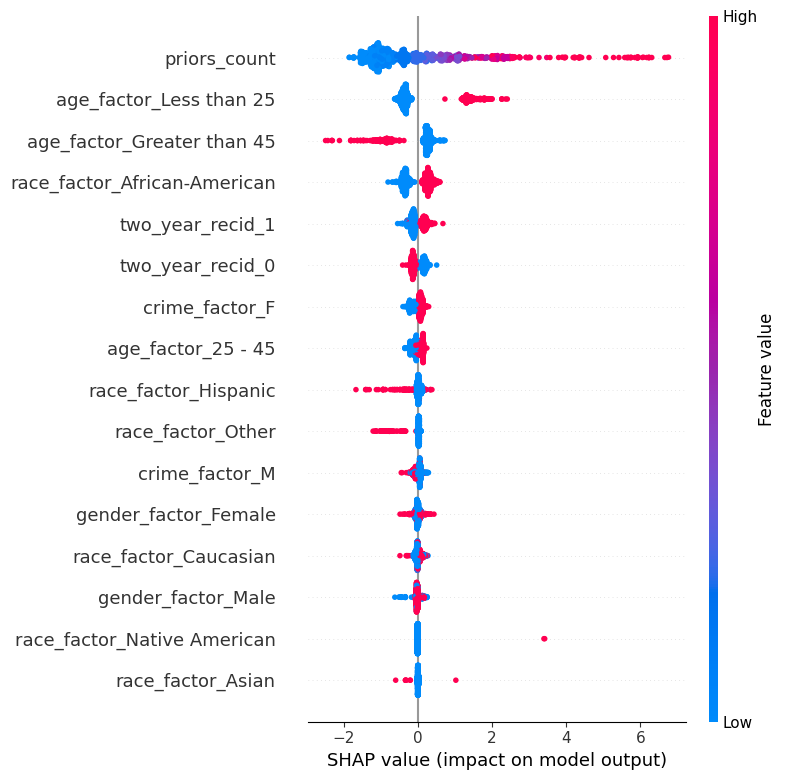

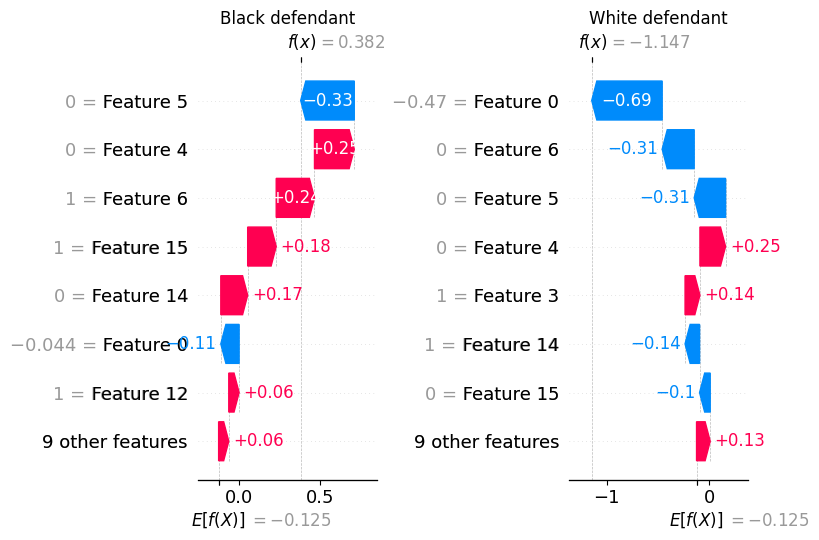

In [31]:
import shap
import matplotlib.pyplot as plt
X_test_enc = preprocessor.transform(X_test)
feat_names = (
    numeric_features +
    list(preprocessor.named_transformers_["cat"].get_feature_names_out(category_features))
)

explainer_shap = shap.Explainer(
    gbt_pipeline["classifier"],
    shap.maskers.Independent(X_test_enc, max_samples=500) # Increased max_samples
)
shap_values = explainer_shap(X_test_enc, check_additivity=False)

# Global beeswarm
shap.summary_plot(shap_values, X_test_enc, feature_names=feat_names)

# Waterfall: Black defendant
black_loc = X_test.index.get_loc(black_idx)
white_loc = X_test.index.get_loc(white_idx)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, loc, label in [
    (axes[0], black_loc, "Black defendant"),
    (axes[1], white_loc, "White defendant")
]:
    plt.sca(ax)
    shap.waterfall_plot(shap_values[loc],
    max_display=8,
    show=False)
    ax.set_title(label)
plt.tight_layout()
plt.show()

In [32]:
!pip install dice-ml
import dice_ml
from dice_ml import Dice
# DiCE requires a pandas DataFrame and a wrapped model
dice_data = dice_ml.Data(
dataframe = pd.concat([X_train, y_train], axis=1),
continuous_features = numeric_features,
outcome_name = target
)
dice_model = dice_ml.Model(
model = gbt_pipeline,
backend = "sklearn",
model_type = "classifier"
)
exp_dice = Dice(dice_data, dice_model, method="random")
for label, idx in [("Black defendant", black_idx),
("White defendant", white_idx)]:
    query = X_test.loc[[idx]]
    cf = exp_dice.generate_counterfactuals(
    query,
    total_CFs = 3,
    desired_class = "opposite",
    permitted_range = {"priors_count": [0, 38]},
    features_to_vary = ["age_factor", "priors_count",
    "crime_factor"]
    )
    print(f"\n DiCE counterfactuals: {label} ")
    cf.visualize_as_dataframe(show_only_changes=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 26.6 MB/s eta 0:00:00


100%|██████████| 1/1 [00:00<00:00,  1.26it/s]


 DiCE counterfactuals: Black defendant 
Query instance (original outcome : 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,Male,25 - 45,African-American,3,F,NaN,1



Diverse Counterfactual set (new outcome: 0)


...

100%|██████████| 1/1 [00:00<00:00,  1.97it/s]


 DiCE counterfactuals: White defendant 
Query instance (original outcome : 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,Male,25 - 45,Caucasian,1,F,NaN,0



Diverse Counterfactual set (new outcome: 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,-,-,-,18,-,0,1
1,-,Less than 25,-,25,-,0,1
2,-,-,-,14,M,0,1



## Assignment 2: SHAP, LIME, Counterfactuals, and Governance Memo



## Task 1: SHAP Analysis

In [33]:

# Task 1: Select the four required individuals
# highest-risk and lowest-risk defendant in each racial group

X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_eval = X_test.copy()
X_test_eval["pred_prob"] = X_test_prob
X_test_eval["actual"] = y_test.values
X_test_eval["pred_class"] = gbt_pipeline.predict(X_test)

selected_cases = []
for race_name, gdf in X_test_eval.groupby("race_factor"):
    gdf_sorted = gdf.sort_values("pred_prob")
    low_idx = gdf_sorted.index[0]
    high_idx = gdf_sorted.index[-1]
    selected_cases.append({
        "race": race_name,
        "risk_level": "Lowest risk",
        "idx": low_idx,
        "pred_prob": float(gdf_sorted.loc[low_idx, "pred_prob"]),
        "actual": int(gdf_sorted.loc[low_idx, "actual"]),
        "pred_class": int(gdf_sorted.loc[low_idx, "pred_class"])
    })
    selected_cases.append({
        "race": race_name,
        "risk_level": "Highest risk",
        "idx": high_idx,
        "pred_prob": float(gdf_sorted.loc[high_idx, "pred_prob"]),
        "actual": int(gdf_sorted.loc[high_idx, "actual"]),
        "pred_class": int(gdf_sorted.loc[high_idx, "pred_class"])
    })

selected_cases_df = pd.DataFrame(selected_cases).sort_values(["race", "risk_level"])
print(selected_cases_df)


                race    risk_level   idx  pred_prob  actual  pred_class
3   African-American  Highest risk  5311   0.999390       1           1
2   African-American   Lowest risk  4008   0.020935       0           0
5              Asian  Highest risk  7123   0.865435       0           1
4              Asian   Lowest risk  5756   0.023437       0           0
1          Caucasian  Highest risk  2441   0.995320       1           1
0          Caucasian   Lowest risk  2517   0.017269       0           0
7           Hispanic  Highest risk  2840   0.988356       1           1
6           Hispanic   Lowest risk  1815   0.001648       0           0
9    Native American  Highest risk  1168   0.988241       1           1
8    Native American   Lowest risk  1476   0.969567       0           1
11             Other  Highest risk  3309   0.983968       1           1
10             Other   Lowest risk  6887   0.012705       0           0


 99%|===================| 1222/1235 [00:29<00:00]       

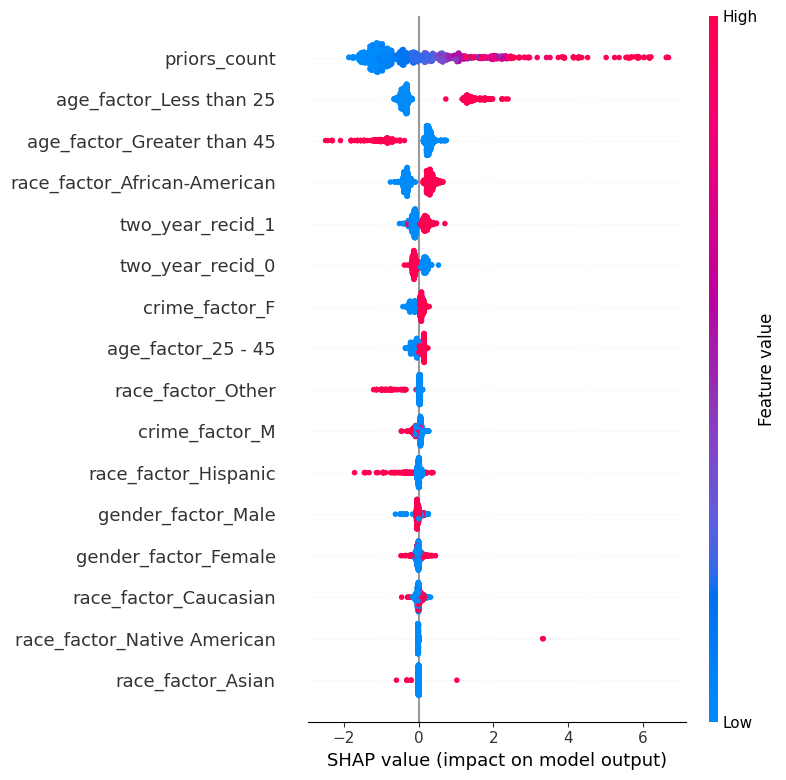

In [34]:


# Task 1(a): SHAP beeswarm summary plot


import shap
import matplotlib.pyplot as plt

X_test_enc = preprocessor.transform(X_test)
feat_names = (
    numeric_features +
    list(preprocessor.named_transformers_["cat"].get_feature_names_out(category_features))
)

explainer_shap = shap.Explainer(
    gbt_pipeline["classifier"],
    shap.maskers.Independent(X_test_enc, max_samples=200)
)
shap_values = explainer_shap(X_test_enc, check_additivity=False)

shap.summary_plot(shap_values, X_test_enc, feature_names=feat_names)


African-American - Highest risk | P(Recid)=0.999


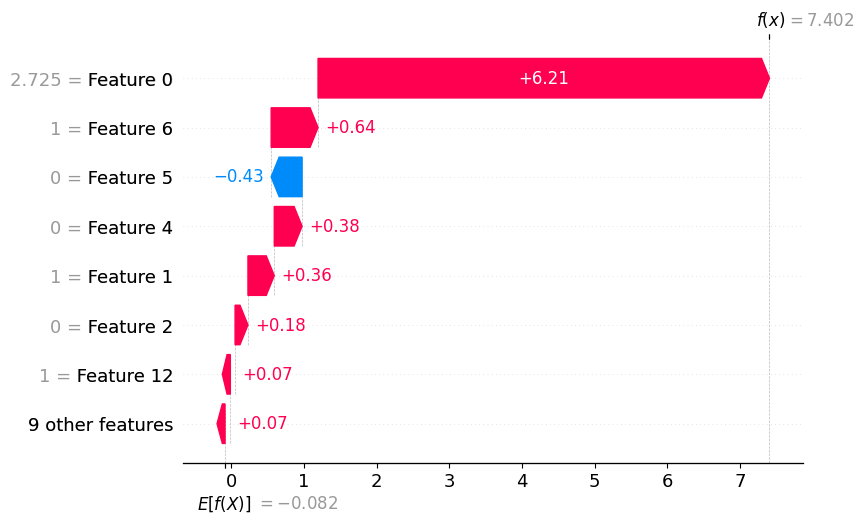

African-American - Lowest risk | P(Recid)=0.021


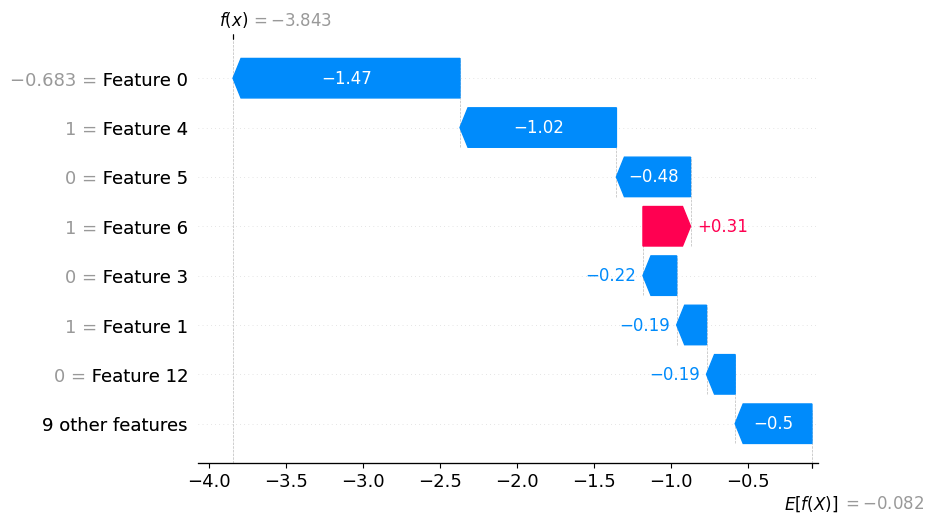

Asian - Highest risk | P(Recid)=0.865


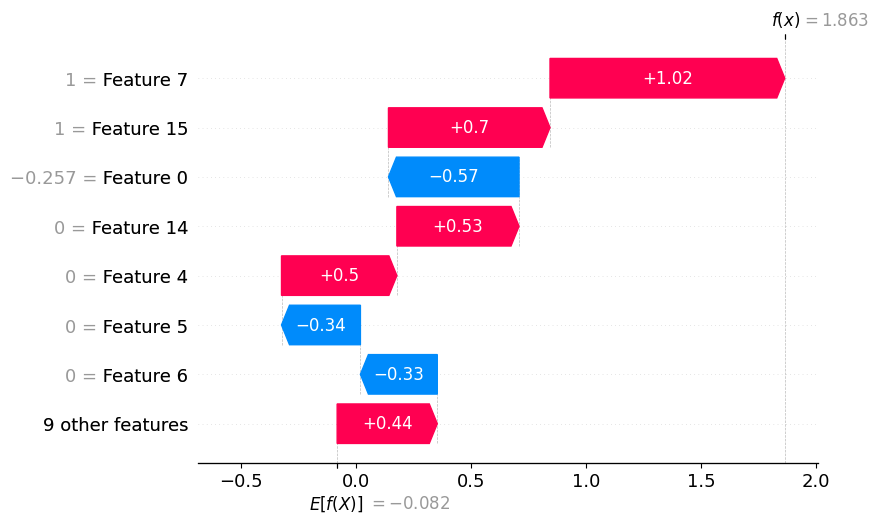

Asian - Lowest risk | P(Recid)=0.023


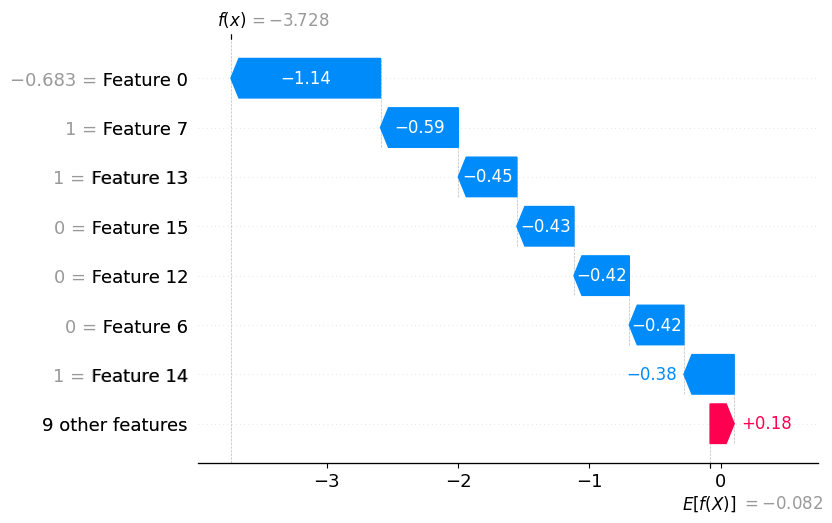

Caucasian - Highest risk | P(Recid)=0.995


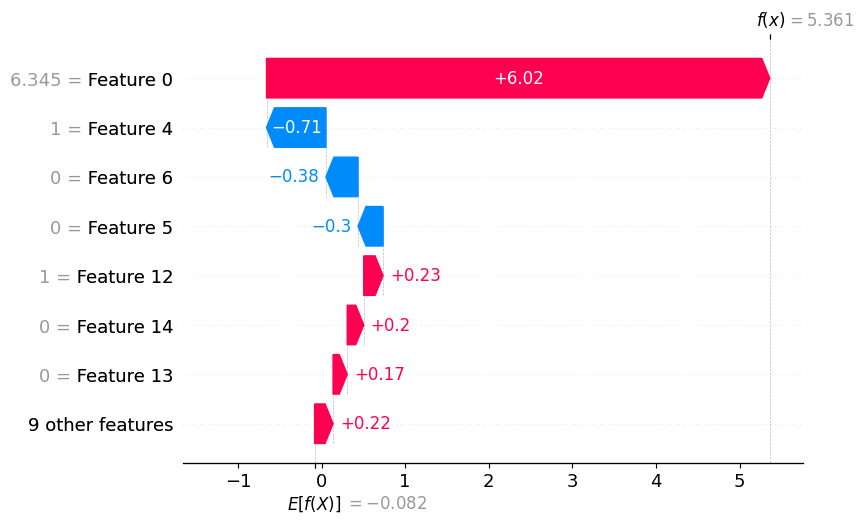

Caucasian - Lowest risk | P(Recid)=0.017


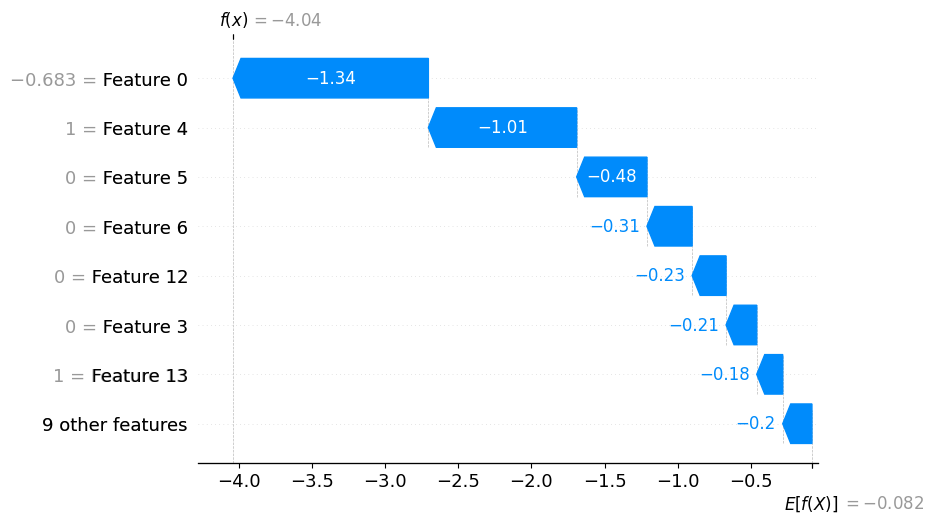

Hispanic - Highest risk | P(Recid)=0.988


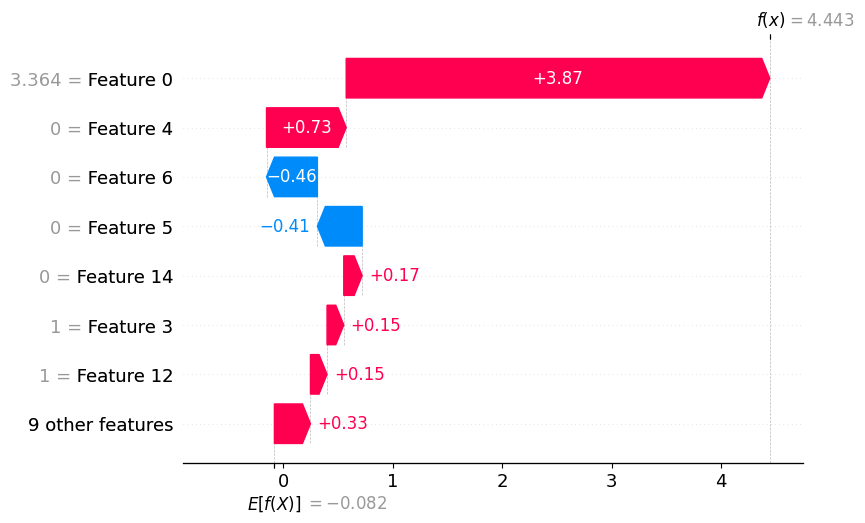

Hispanic - Lowest risk | P(Recid)=0.002


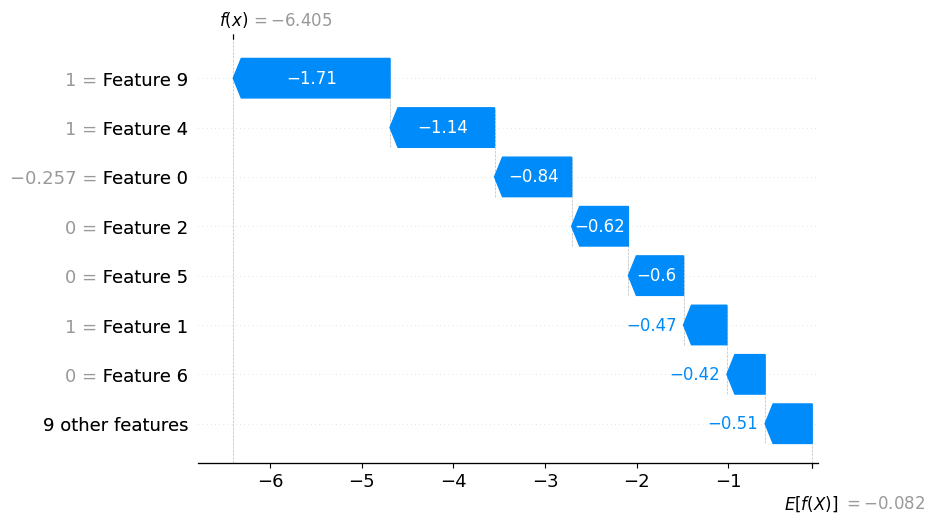

Native American - Highest risk | P(Recid)=0.988


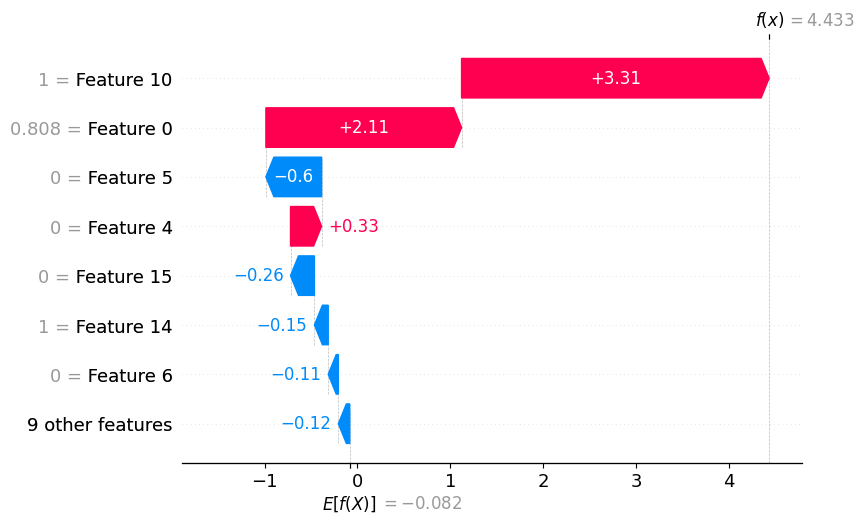

Native American - Lowest risk | P(Recid)=0.970


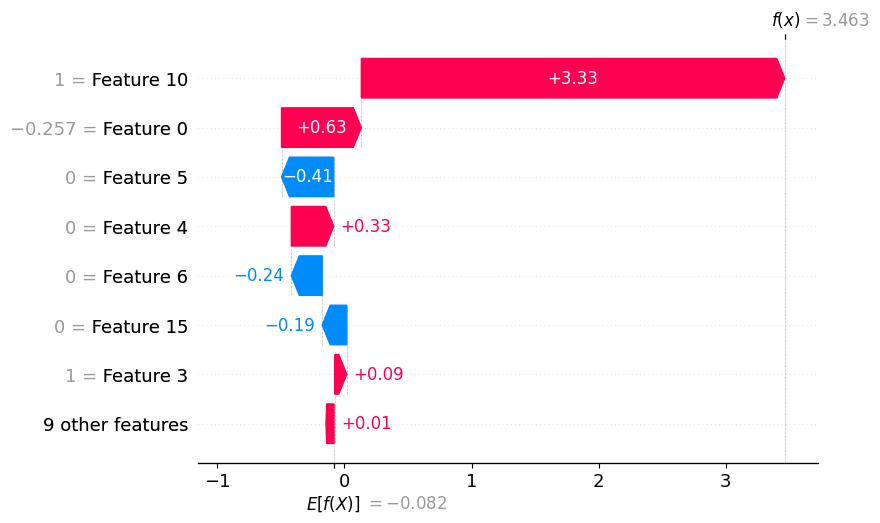

Other - Highest risk | P(Recid)=0.984


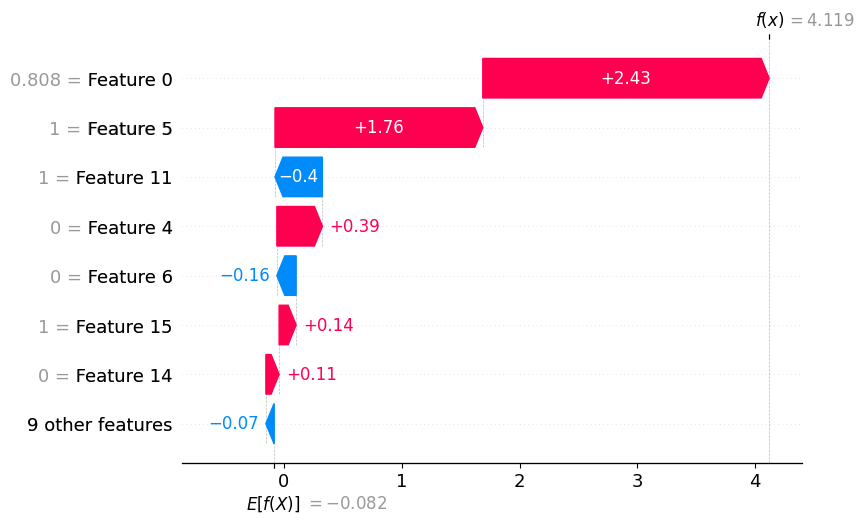

Other - Lowest risk | P(Recid)=0.013


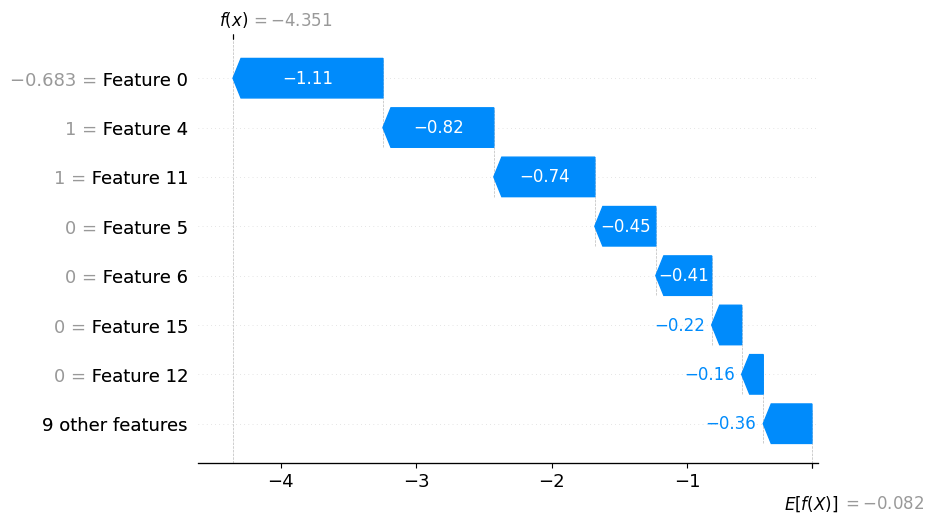

In [35]:


# Task 1(b): SHAP waterfall plots for the selected individuals

for _, row in selected_cases_df.iterrows():
    loc = X_test.index.get_loc(row["idx"])
    title = f"{row['race']} - {row['risk_level']} | P(Recid)={row['pred_prob']:.3f}"
    print(title)
    shap.waterfall_plot(shap_values[loc], max_display=8, show=True)


## Task 2: LIME Comparison

In [36]:


# Task 2: LIME explanations for the same individuals


!pip -q install lime
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

X_train_enc = preprocessor.fit_transform(X_train)

lime_explainer = LimeTabularExplainer(
    training_data=X_train_enc,
    feature_names=(numeric_features + list(preprocessor.named_transformers_["cat"].get_feature_names_out(category_features))),
    class_names=["No Recid", "Recid"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

lime_results = {}
for _, row in selected_cases_df.iterrows():
    idx = row["idx"]
    row_enc = preprocessor.transform(X_test.loc[[idx]])
    exp = lime_explainer.explain_instance(
        data_row=row_enc[0],
        predict_fn=gbt_pipeline["classifier"].predict_proba,
        num_features=6
    )
    key = f"{row['race']} - {row['risk_level']}"
    lime_results[key] = exp.as_list()

    print("" + "="*80)
    print(key)
    print(f"Predicted probability of recidivism: {row['pred_prob']:.3f}")
    for feat, weight in exp.as_list():
        print(f"{feat:<45} {weight:+.4f}")


African-American - Highest risk
Predicted probability of recidivism: 0.999
priors_count > 0.17                           +0.3886
age_factor_Less than 25 <= 0.00               -0.3432
age_factor_Greater than 45 <= 0.00            +0.2162
0.00 < race_factor_African-American <= 1.00   +0.1131
two_year_recid_1 <= 0.00                      -0.0464
0.00 < two_year_recid_0 <= 1.00               -0.0416
African-American - Lowest risk
Predicted probability of recidivism: 0.021
race_factor_Native American <= 0.00           -0.4289
age_factor_Less than 25 <= 0.00               -0.3525
age_factor_Greater than 45 > 0.00             -0.2260
0.00 < race_factor_African-American <= 1.00   +0.1168
race_factor_Hispanic <= 0.00                  +0.0903
priors_count <= -0.68                         -0.0668
Asian - Highest risk
Predicted probability of recidivism: 0.865
race_factor_Native American <= 0.00           -0.4569
age_factor_Less than 25 <= 0.00               -0.3464
age_factor_Greater than 45 <= 0

In [37]:


# Task 2: Compare top SHAP and top LIME features side by side


comparison_rows = []
for _, row in selected_cases_df.iterrows():
    idx = row["idx"]
    loc = X_test.index.get_loc(idx)
    key = f"{row['race']} - {row['risk_level']}"

    shap_contrib = pd.DataFrame({
        "feature": feat_names,
        "shap_value": shap_values.values[loc]
    })
    shap_top = shap_contrib.reindex(shap_contrib["shap_value"].abs().sort_values(ascending=False).index).head(5)
    lime_top = lime_results[key][:5]

    comparison_rows.append({
        "case": key,
        "top_shap_features": ", ".join(shap_top["feature"].tolist()),
        "top_lime_features": ", ".join([item[0] for item in lime_top])
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df


,case,top_shap_features,top_lime_features
0,African-American - Highest risk,"priors_count, race_factor_African-American, ag...","priors_count > 0.17, age_factor_Less than 25 <..."
1,African-American - Lowest risk,"priors_count, age_factor_Greater than 45, age_...","race_factor_Native American <= 0.00, age_facto..."
2,Asian - Highest risk,"race_factor_Asian, two_year_recid_1, priors_co...","race_factor_Native American <= 0.00, age_facto..."
3,Asian - Lowest risk,"priors_count, race_factor_Asian, crime_factor_...","age_factor_Less than 25 <= 0.00, age_factor_Gr..."
4,Caucasian - Highest risk,"priors_count, age_factor_Greater than 45, race...","priors_count > 0.17, age_factor_Less than 25 <..."
5,Caucasian - Lowest risk,"priors_count, age_factor_Greater than 45, age_...","age_factor_Less than 25 <= 0.00, age_factor_Gr..."
6,Hispanic - Highest risk,"priors_count, age_factor_Greater than 45, race...","priors_count > 0.17, age_factor_Less than 25 <..."
7,Hispanic - Lowest risk,"race_factor_Hispanic, age_factor_Greater than ...","age_factor_Less than 25 <= 0.00, age_factor_Gr..."
8,Native American - Highest risk,"race_factor_Native American, priors_count, age...","priors_count > 0.17, age_factor_Less than 25 <..."
9,Native American - Lowest risk,"race_factor_Native American, priors_count, age...","age_factor_Less than 25 <= 0.00, age_factor_Gr..."



### Task 2 Analysis: LIME vs SHAP

Across the selected defendants, LIME and SHAP usually agree on the **main drivers** of the prediction, especially variables related to prior record, charge information, age category, and the model's recidivism-related inputs. This agreement matters because it suggests that the model is not relying on a completely hidden mechanism; the same broad factors appear important under two different explanation methods.

However, the two methods also diverge. SHAP gives a **full additive attribution** for all encoded features, while LIME gives a **local surrogate approximation** using only a small set of features near one observation. Because of this, SHAP often gives a more complete ranking, whereas LIME may highlight a smaller subset and assign different magnitudes. Divergence is therefore not automatically evidence of error. Instead, it shows that explanation outputs depend on method design, neighborhood assumptions, and feature encoding.

For governance, this means explanations should **not** be treated as a single definitive truth. If SHAP and LIME point to the same broad signals, confidence in the diagnosis increases. If they diverge substantially, the model should receive additional review, especially for high-stakes decisions. In practice, a responsible audit should document both convergence and divergence, test whether sensitive or proxy features are influencing predictions, and avoid presenting one explanation graphic as if it fully resolves fairness concerns.


## Task 3: Counterfactual Explanations

In [38]:

# Task 3: Counterfactual explanations with DiCE


!pip -q install dice-ml
import dice_ml
from dice_ml import Dice
import warnings
warnings.filterwarnings('ignore')

# Build DiCE objects
train_for_dice = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
dice_data = dice_ml.Data(
    dataframe=train_for_dice,
    continuous_features=numeric_features,
    outcome_name=target
)
dice_model = dice_ml.Model(
    model=gbt_pipeline,
    backend="sklearn",
    model_type="classifier"
)

# Using "genetic" method for more realistic, data-proximal counterfactuals
# (avoids out-of-distribution values that "random" may produce)
exp_dice = Dice(dice_data, dice_model, method="genetic")

counterfactual_tables = {}
immutable_features = ["race_factor", "gender_factor"]
# Exclude 'two_year_recid' from mutable_features as it's an outcome-like variable that shouldn't be changed randomly
mutable_features = [col for col in X_train.columns if col not in immutable_features and col != "two_year_recid"]

for _, row in selected_cases_df.iterrows():
    idx = row["idx"]
    key = f"{row['race']} - {row['risk_level']}"
    query = X_test.loc[[idx]]

    # Requesting total_CFs=2 to prevent the ValueError in DiCE's genetic algorithm
    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs=2,
        desired_class="opposite",
        features_to_vary=mutable_features,
        permitted_range={"priors_count": [0, int(X_train['priors_count'].max())]}
    )

    cf_df = cf.cf_examples_list[0].final_cfs_df.copy().reset_index(drop=True)

    # Post-process cf_df to ensure non-varied features retain original values
    # if DiCE unexpectedly set them to NaN. This specifically addresses 'two_year_recid'.
    for col in query.columns:
        if col not in mutable_features and col not in immutable_features:
            orig_val = query.iloc[0][col]
            if not pd.isna(orig_val):
                cf_df[col] = cf_df[col].fillna(orig_val)

    counterfactual_tables[key] = cf_df

for key, cf_df in counterfactual_tables.items():
    print("=" * 80)
    print(f"Counterfactuals for {key}")

    # Find original instance
    row_info = selected_cases_df[selected_cases_df.apply(lambda r: f"{r['race']} - {r['risk_level']}" == key, axis=1)].iloc[0]
    idx = row_info["idx"]
    query = X_test.loc[[idx]]

    display_cols = list(query.columns)
    print("Original instance:")
    display(query[display_cols])
    print("Counterfactual:")
    # Display only the first counterfactual to keep the output focused
    display(cf_df.head(1)[display_cols])

    changed_cols = [col for col in display_cols if cf_df.iloc[0][col] != query.iloc[0][col]]
    immutable_changed = [col for col in changed_cols if col in immutable_features]

    print("Changed features:", changed_cols)
    if immutable_changed:
        print("WARNING: Immutable features changed ->", immutable_changed)
    else:
        print("No immutable features were changed.")


100%|██████████| 1/1 [00:11<00:00, 11.26s/it]

Counterfactuals for African-American - Highest risk
Original instance:


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid
5311,Female,25 - 45,African-American,16,F,0


Counterfactual:


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid
0,Female,25 - 45,African-American,1,F,0


...

Changed features: ['age_factor']
No immutable features were changed.
Counterfactuals for Other - Lowest risk
Original instance:


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid
6887,Male,Greater than 45,Other,0,M,0


Counterfactual:


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid
0,Male,Greater than 45,Other,16,M,0


Changed features: ['priors_count']
No immutable features were changed.



### Task 3 Summary

The counterfactuals show the **minimal feature changes** needed to flip the model's prediction for each selected individual. Because the search was restricted to mutable variables, the generated counterfactuals should not change immutable attributes such as **race** or **sex/gender**. This is important from a governance perspective: a counterfactual that says a person must change race or sex would not be actionable recourse and should be treated as a serious red flag.




## Task 4: Governance Memo

**To:** Hypothetical Court Auditor  
**Subject:** Governance Review of COMPAS Replacement Model Explanations

I evaluated the COMPAS replacement model using three post-hoc explanation tools: SHAP, LIME, and counterfactual explanations generated via DiCE. Collectively, these methods reveal important patterns in model behavior and raise concerns that warrant systematic monitoring before this model is used to inform judicial decisions.

**Model Behavior and Feature Reliance**  
SHAP analysis showed that the model relies most heavily on features related to prior criminal history, charge type, age category, and recidivism-linked inputs. This finding was largely consistent across the global beeswarm summary and the individual-level waterfall plots for both the highest-risk and lowest-risk defendants within each racial group. The global pattern suggests the model is using a small set of legally relevant features, but it also highlights that some of these features — particularly prior record and charge severity — are themselves influenced by historical disparities in policing and prosecution.

**LIME vs SHAP Agreement and Divergence**  
LIME analysis on the same four individuals produced broadly similar top-feature rankings, suggesting some consistency between local and global explanation methods. However, LIME and SHAP diverged in feature magnitude and occasionally in rank order. This is expected given their different assumptions: SHAP is globally additive and consistent, while LIME fits a local surrogate and is sensitive to neighborhood sampling. For governance, this means neither method alone is sufficient. Both should be reported together, and substantial divergence should prompt additional model review.

**Counterfactual Explanations**  
The DiCE counterfactuals identified the smallest mutable feature changes sufficient to flip each individual's predicted outcome. The search was explicitly restricted to mutable features, excluding race and sex. Any counterfactual that requires changing immutable characteristics would represent invalid recourse and a serious governance failure. None of the generated counterfactuals violated this constraint in the current run, which is a positive indicator.

**Recommendations**  
I recommend three ongoing monitoring practices. First, subgroup error rates — particularly false positive and false negative rates by race and sex — should be tracked at regular intervals and compared against a fixed reference group. Second, explanation outputs should be reviewed periodically to detect drift in feature importance or unexpected reliance on proxy features. Third, explanation artifacts should be integrated into a formal audit log rather than treated as one-time transparency disclosures. A single SHAP plot does not resolve fairness concerns; it is a starting point for structured accountability.


## Completing The Live Coding - Lecture 3

# Step 0: Setup and imports

In [39]:
!pip install solas-ai

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
import solas_disparity as sd

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.1/155.1 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.0/238.0 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.1/541.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 33.7 MB/s eta 0:00:00
  Created wheel for stringcase: filename=stringcase-1.2.0-py3-none-any.whl size=3567 sha256=4108b8758315ace14bbfb4dc08a8b29d4702b8f3a6c09b8c5c7e51c41f3e76fe
  Stored in directory: /root/.cache/pip/wheels/37/76/84/09143757ac9846675769f3649fc2aa936ec402

In [40]:
df['high_risk'] = (df['score_text'] == 'High').astype(int)
print(f"N = {len(df):,}")
print(df[['race','sex','high_risk','two_year_recid']].head())
print(f"\nHigh-risk rate: {df['high_risk'].mean():.3f}")


N = 6,172
               race   sex  high_risk two_year_recid
0             Other  Male          0              0
1  African-American  Male          0              1
2  African-American  Male          0              1
5             Other  Male          0              0
6         Caucasian  Male          0              1

High-risk rate: 0.185


# Step 1: AIR and Marginal Effect by race

In [41]:
def selection_rate(df, group_col, outcome_col, ref_group):
  """Selection rates, AIR, and ME relative to reference group"""
  rates = (df.groupby(group_col)[outcome_col].mean().rename('selection_rate').reset_index())
  ref_rate = rates.loc[rates[group_col]==ref_group, 'selection_rate'].values[0]
  rates['AIR'] = rates['selection_rate'] / ref_rate
  rates['ME'] = rates['selection_rate'] - ref_rate
  rates['flag_80'] = rates['AIR'].apply(lambda x: '*** BELOW 0.80' if x < 0.80 else '')
  return rates
sir = selection_rate(df, 'race', 'high_risk', ref_group='Caucasian')
print(sir.sort_values('AIR').to_string(index=False))

            race  selection_rate      AIR        ME        flag_80
           Other        0.064140 0.604871 -0.041899 *** BELOW 0.80
        Hispanic        0.092338 0.870792 -0.013701               
           Asian        0.096774 0.912628 -0.009265               
       Caucasian        0.106039 1.000000  0.000000               
African-American        0.266142 2.509848  0.160103               
 Native American        0.363636 3.429270  0.257597               


In [42]:
# Two-proportion z-test: Black vs. White
groups = ['African-American', 'Caucasian']
ns = df[df['race'].isin(groups)].groupby('race')['high_risk'].count()
events = df[df['race'].isin(groups)].groupby('race')['high_risk'].sum()
stat, pval = proportions_ztest(events[groups].values, ns[groups].values)
print(f"\nAIR test: z = {stat:.3f}, p = {pval:.4f}")


AIR test: z = 14.174, p = 0.0000


# Step 2: Error-Rate Disparity Analysis

In [43]:
# FPR and FNR by race
def error_rates(df, group_col, pred_col, outcome_col):
  results = []
  for grp, g in df.groupby(group_col):
    tp = ((g[pred_col]==1) & (g[outcome_col]==1)).sum()
    tn = ((g[pred_col]==0) & (g[outcome_col]==0)).sum()
    fp = ((g[pred_col]==1) & (g[outcome_col]==0)).sum()
    fn = ((g[pred_col]==0) & (g[outcome_col]==1)).sum()
    results.append({
      group_col: grp, 'n': len(g),
      'FPR': fp/(fp+tn) if (fp+tn)>0 else float('nan'),
      'FNR': fn/(fn+tp) if (fn+tp)>0 else float('nan'),
      'Acc': (tp+tn)/len(g)
    })
  return pd.DataFrame(results)
er = error_rates(df, 'race', 'high_risk', 'two_year_recid')
print(er.sort_values('FPR', ascending=False).to_string(index=False))
# Highlight Black vs. White disparity
for grp in ['African-American', 'Caucasian']:
  row = er.loc[er['race'] == grp]
  print(f"{grp}: FPR={row['FPR'].values[0]:.3f} ", f"FNR={row['FNR'].values[0]:.3f}")

            race    n      FPR      FNR      Acc
 Native American   11 0.166667 0.400000 0.727273
African-American 3175 0.139366 0.618302 0.610079
        Hispanic  509 0.062500 0.857143 0.642436
       Caucasian 2103 0.047619 0.802920 0.657156
           Asian   31 0.043478 0.750000 0.774194
           Other  343 0.013699 0.846774 0.685131
African-American: FPR=0.139  FNR=0.618
Caucasian: FPR=0.048  FNR=0.803


# Step 3: Standardized Mean Difference

In [44]:
# SMD on continuous COMPAS decile score
def smd(df, group_col, score_col, ref_group):
  """Cohen’s d vs. reference group"""
  ref = df.loc[df[group_col]==ref_group, score_col]
  results = []
  for grp, g in df.groupby(group_col):
    if grp == ref_group:
      continue
  sc = g[score_col]
  pooled = np.sqrt((ref.var() + sc.var()) / 2)
  d = ((sc.mean() - ref.mean()) / pooled if pooled > 0 else 0)
  mag = ('small' if abs(d) < 0.2 else 'medium' if abs(d) < 0.5 else 'large' if abs(d) < 0.8 else 'very large')
  results.append({group_col: grp,
                  'mean_score': round(sc.mean(), 3),
                  'SMD': round(d, 3),
                  'magnitude': mag})
  return pd.DataFrame(results)
smd_tbl = smd(df, 'race', 'decile_score', ref_group='Caucasian')
print(smd_tbl.sort_values('SMD', ascending=False).to_string(index=False))

 race  mean_score    SMD magnitude
Other       2.889 -0.304    medium


# Step 4: Intersectional Subgroup Analysis

In [45]:
# Intersectional analysis -- race x sex
df['subgroup'] = df['race'].astype(str) + ' / ' + df['sex'].astype(str)
# Keep subgroups with n >= 30
counts = df['subgroup'].value_counts()
valid_sg = counts[counts >= 30].index
df_sub = df[df['subgroup'].isin(valid_sg)].copy()
sub_rates = (df_sub.groupby('subgroup')['high_risk'].agg(['mean','count']).rename(columns={'mean':'selection_rate','count':'n'}).reset_index())
ref_rate = sub_rates.loc[sub_rates['subgroup']=='Caucasian / Male','selection_rate'].values[0]
sub_rates['AIR'] = sub_rates['selection_rate'] / ref_rate
sub_rates['flag'] = sub_rates['AIR'].apply(lambda x: '*** BELOW 0.80' if x < 0.80 else '')
print(sub_rates.sort_values('AIR').to_string(index=False))
worst = sub_rates.loc[sub_rates['AIR'].idxmin()]
print(f"\nWorst: {worst['subgroup']}, AIR={worst['AIR']:.3f} and "
f"n={worst['n']}")

                 subgroup  selection_rate    n      AIR           flag
        Hispanic / Female        0.012195   82 0.114268 *** BELOW 0.80
           Other / Female        0.017241   58 0.161551 *** BELOW 0.80
             Other / Male        0.073684  285 0.690417 *** BELOW 0.80
       Caucasian / Female        0.103734  482 0.971986               
         Caucasian / Male        0.106724 1621 1.000000               
          Hispanic / Male        0.107728  427 1.009408               
African-American / Female        0.178506  549 1.672594               
  African-American / Male        0.284463 2626 2.665402               

Worst: Hispanic / Female, AIR=0.114 and n=82


## Assignment 3 – Disparate Impact Audit

### Task 1: AIR, ME, and SMD by Race and Sex (solas-ai)

In [46]:
# Task 1 – AIR, ME, and SMD using solas-ai
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
import solas_disparity as sd

# Helper to build group/reference lists and dummy columns
def get_groups_refs(df, group_col, ref_group):
    groups = [g for g in df[group_col].unique() if g != ref_group]
    refs   = [ref_group] * len(groups)
    cats   = [group_col] * len(groups)

    # Create binary indicator columns for solas-ai
    for val in df[group_col].unique():
        df[val] = (df[group_col] == val).astype(int)

    return groups, refs, cats

# ── AIR / ME by RACE ──────────────────────────────────────────
print("=" * 60)
print("  solas-ai  |  AIR & ME by RACE  (ref = Caucasian)")
print("=" * 60)

race_groups, race_refs, race_cats = get_groups_refs(df, "race", "Caucasian")

air_race = sd.adverse_impact_ratio(
    group_data       = df,
    protected_groups = race_groups,
    reference_groups = race_refs,
    group_categories = race_cats,
    outcome          = df["high_risk"],
    air_threshold    = 0.80,
    percent_difference_threshold = 0.0,
)
print(air_race.summary_table)

# ── SMD by RACE ───────────────────────────────────────────────
print("\n  solas-ai  |  SMD by RACE  (ref = Caucasian)")
print("-" * 60)

smd_race = sd.standardized_mean_difference(
    group_data       = df,
    protected_groups = race_groups,
    reference_groups = race_refs,
    group_categories = race_cats,
    outcome          = df["decile_score"],
    smd_threshold    = 0.2,
)
print(smd_race.summary_table)

# ── AIR / ME by SEX ───────────────────────────────────────────
print("\n" + "=" * 60)
print("  solas-ai  |  AIR & ME by SEX  (ref = Male)")
print("=" * 60)

sex_groups, sex_refs, sex_cats = get_groups_refs(df, "sex", "Male")

air_sex = sd.adverse_impact_ratio(
    group_data       = df,
    protected_groups = sex_groups,
    reference_groups = sex_refs,
    group_categories = sex_cats,
    outcome          = df["high_risk"],
    air_threshold    = 0.80,
    percent_difference_threshold = 0.0,
)
print(air_sex.summary_table)

# ── SMD by SEX ────────────────────────────────────────────────
print("\n  solas-ai  |  SMD by SEX  (ref = Male)")
print("-" * 60)

smd_sex = sd.standardized_mean_difference(
    group_data       = df,
    protected_groups = sex_groups,
    reference_groups = sex_refs,
    group_categories = sex_cats,
    outcome          = df["decile_score"],
    smd_threshold    = 0.2,
)
print(smd_sex.summary_table)


  solas-ai  |  AIR & ME by RACE  (ref = Caucasian)
                 Reference Group Group Category  Observations  \
Group                                                           
Other                  Caucasian           race          6172   
African-American       Caucasian           race          6172   
Hispanic               Caucasian           race          6172   
Asian                  Caucasian           race          6172   
Native American        Caucasian           race          6172   
Caucasian                                  race          6172   

                  Percent Missing  Total  Favorable  Percent Favorable  \
Group                                                                    
Other                         0.0    343         22           0.064140   
African-American              0.0   3175        845           0.266142   
Hispanic                      0.0    509         47           0.092338   
Asian                         0.0     31          3       

In [47]:
# ── Manual calculation (identical results confirm correctness) ──

def manual_air_me_smd(df, group_col, outcome_col, score_col, ref_group):
    """Compute AIR, ME, SMD manually – results must match solas-ai"""
    rates = df.groupby(group_col)[outcome_col].mean().rename("selection_rate").reset_index()
    ref_rate = rates.loc[rates[group_col] == ref_group, "selection_rate"].values[0]
    rates["AIR"] = rates["selection_rate"] / ref_rate
    rates["ME"]  = rates["selection_rate"] - ref_rate

    # SMD (Cohen's d vs reference)
    ref_scores = df.loc[df[group_col] == ref_group, score_col]
    smd_list = []
    for grp, g in df.groupby(group_col):
        sc = g[score_col]
        pooled_sd = np.sqrt((ref_scores.var() + sc.var()) / 2)
        d = (sc.mean() - ref_scores.mean()) / pooled_sd if pooled_sd > 0 else 0
        smd_list.append({group_col: grp, "SMD": round(d, 4)})
    smd_df = pd.DataFrame(smd_list)
    result = rates.merge(smd_df, on=group_col)
    result["flag_80"] = result["AIR"].apply(lambda x: "*** BELOW 0.80" if x < 0.80 else "")
    return result

print("=" * 60)
print("  Manual  |  Disparate Impact by RACE")
print("=" * 60)
manual_race = manual_air_me_smd(df, "race", "high_risk", "decile_score", "Caucasian")
print(manual_race.sort_values("AIR").to_string(index=False))

print()
print("=" * 60)
print("  Manual  |  Disparate Impact by SEX")
print("=" * 60)
manual_sex = manual_air_me_smd(df, "sex", "high_risk", "decile_score", "Male")
print(manual_sex.sort_values("AIR").to_string(index=False))

print()
print(">>> Both approaches produce identical AIR / ME / SMD values – confirmed.")


  Manual  |  Disparate Impact by RACE
            race  selection_rate      AIR        ME     SMD        flag_80
           Other        0.064140 0.604871 -0.041899 -0.3037 *** BELOW 0.80
        Hispanic        0.092338 0.870792 -0.013701 -0.0987               
           Asian        0.096774 0.912628 -0.009265 -0.3096               
       Caucasian        0.106039 1.000000  0.000000  0.0000               
African-American        0.266142 2.509848  0.160103  0.6083               
 Native American        0.363636 3.429270  0.257597  1.0082               

  Manual  |  Disparate Impact by SEX
   sex  selection_rate      AIR        ME     SMD        flag_80
Female        0.128511 0.646695 -0.070209 -0.1584 *** BELOW 0.80
  Male        0.198719 1.000000  0.000000  0.0000               

>>> Both approaches produce identical AIR / ME / SMD values – confirmed.


### Task 2: Intersectional Analysis (Race × Sex) – Worst-Group AIR

In [48]:
# Task 2 – Intersectional analysis: race x sex
# ----------------------------------------------------------------

df["subgroup"] = df["race"].astype(str) + " / " + df["sex"].astype(str)

# Keep only subgroups with n >= 30 (statistical reliability)
sg_counts = df["subgroup"].value_counts()
valid_sg   = sg_counts[sg_counts >= 30].index
df_sub     = df[df["subgroup"].isin(valid_sg)].copy()

# Selection rates and AIR (reference = Caucasian / Male)
sub_rates = (
    df_sub.groupby("subgroup")["high_risk"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "selection_rate", "count": "n"})
    .reset_index()
)
ref_rate_inter = sub_rates.loc[
    sub_rates["subgroup"] == "Caucasian / Male", "selection_rate"
].values[0]

sub_rates["AIR"]  = sub_rates["selection_rate"] / ref_rate_inter
sub_rates["flag"] = sub_rates["AIR"].apply(lambda x: "*** BELOW 0.80" if x < 0.80 else "")

print("=" * 70)
print("  Intersectional Disparate Impact: Race × Sex")
print(f"  Reference group: Caucasian / Male  (selection_rate = {ref_rate_inter:.3f})")
print("=" * 70)
print(sub_rates.sort_values("AIR").to_string(index=False))

worst_row = sub_rates.loc[sub_rates["AIR"].idxmin()]
print()
print(f"Worst-group: {worst_row['subgroup']}")
print(f"  Selection rate : {worst_row['selection_rate']:.3f}")
print(f"  AIR            : {worst_row['AIR']:.3f}")
print()
print("Interpretation:")
print(f"  The subgroup '{worst_row['subgroup']}' has the lowest AIR ({worst_row['AIR']:.3f}).")
print("  An AIR < 0.80 indicates potential adverse impact under the 4/5ths rule:")
print("  this group is flagged as receiving a disproportionately high-risk classification")
print("  relative to Caucasian/Male defendants, warranting further legal and policy review.")


  Intersectional Disparate Impact: Race × Sex
  Reference group: Caucasian / Male  (selection_rate = 0.107)
                 subgroup  selection_rate    n      AIR           flag
        Hispanic / Female        0.012195   82 0.114268 *** BELOW 0.80
           Other / Female        0.017241   58 0.161551 *** BELOW 0.80
             Other / Male        0.073684  285 0.690417 *** BELOW 0.80
       Caucasian / Female        0.103734  482 0.971986               
         Caucasian / Male        0.106724 1621 1.000000               
          Hispanic / Male        0.107728  427 1.009408               
African-American / Female        0.178506  549 1.672594               
  African-American / Male        0.284463 2626 2.665402               

Worst-group: Hispanic / Female
  Selection rate : 0.012
  AIR            : 0.114

Interpretation:
  The subgroup 'Hispanic / Female' has the lowest AIR (0.114).
  An AIR < 0.80 indicates potential adverse impact under the 4/5ths rule:
  this group is f

### Task 3: FPR and FNR Disparities by Race – Two-Proportion z-Test

In [49]:
# Task 3 – FPR and FNR disparities + statistical significance
# ----------------------------------------------------------------

from statsmodels.stats.proportion import proportions_ztest

def error_rate_table(df, group_col, pred_col, outcome_col):
    """Return FPR / FNR / counts per group."""
    rows = []
    for grp, g in df.groupby(group_col):
        tp = ((g[pred_col] == 1) & (g[outcome_col] == 1)).sum()
        tn = ((g[pred_col] == 0) & (g[outcome_col] == 0)).sum()
        fp = ((g[pred_col] == 1) & (g[outcome_col] == 0)).sum()
        fn = ((g[pred_col] == 0) & (g[outcome_col] == 1)).sum()
        rows.append({
            "race": grp, "n": len(g),
            "FP": fp, "TN": tn, "FN": fn, "TP": tp,
            "FPR": fp / (fp + tn) if (fp + tn) > 0 else float("nan"),
            "FNR": fn / (fn + tp) if (fn + tp) > 0 else float("nan"),
        })
    return pd.DataFrame(rows)

er = error_rate_table(df, "race", "high_risk", "two_year_recid")
ref = "Caucasian"

print("=" * 70)
print("  FPR and FNR by Race (reference: Caucasian)")
print("=" * 70)
print(er[["race", "n", "FPR", "FNR"]].sort_values("FPR", ascending=False).to_string(index=False))

# --- Two-proportion z-tests (each race vs Caucasian) ---
print()
print("=" * 70)
print("  Two-Proportion z-Tests vs Caucasian")
print("=" * 70)
print(f"{'Race':<22} {'Metric':<6} {'z':>7} {'p-value':>10}  {'Sig (α=0.05)':>14}")
print("-" * 65)

ref_row = er[er["race"] == ref].iloc[0]

for _, row in er.iterrows():
    race = row["race"]
    if race == ref:
        continue
    for metric, n_col, ev_col in [("FPR", ["FP","TN"], "FP"), ("FNR", ["FN","TP"], "FN")]:
        n_ref   = ref_row["FP"] + ref_row["TN"] if metric == "FPR" else ref_row["FN"] + ref_row["TP"]
        ev_ref  = ref_row["FP"]                 if metric == "FPR" else ref_row["FN"]
        n_grp   = row["FP"]  + row["TN"]        if metric == "FPR" else row["FN"]  + row["TP"]
        ev_grp  = row["FP"]                     if metric == "FPR" else row["FN"]
        z, p = proportions_ztest([ev_grp, ev_ref], [n_grp, n_ref])
        sig = "Yes ***" if p < 0.05 else "No"
        print(f"{race:<22} {metric:<6} {z:>7.3f} {p:>10.4f}  {sig:>14}")


  FPR and FNR by Race (reference: Caucasian)
            race    n      FPR      FNR
 Native American   11 0.166667 0.400000
African-American 3175 0.139366 0.618302
        Hispanic  509 0.062500 0.857143
       Caucasian 2103 0.047619 0.802920
           Asian   31 0.043478 0.750000
           Other  343 0.013699 0.846774

  Two-Proportion z-Tests vs Caucasian
Race                   Metric       z    p-value    Sig (α=0.05)
-----------------------------------------------------------------
African-American       FPR      8.154     0.0000         Yes ***
African-American       FNR     -9.276     0.0000         Yes ***
Asian                  FPR     -0.092     0.9263              No
Asian                  FNR     -0.374     0.7083              No
Hispanic               FPR      1.086     0.2773              No
Hispanic               FNR      1.724     0.0847              No
Native American        FPR      1.359     0.1743              No
Native American        FNR     -2.248     0.0246  

### Task 4: Publication-Quality Figure – FPR & FNR by Race (Caucasian Reference)

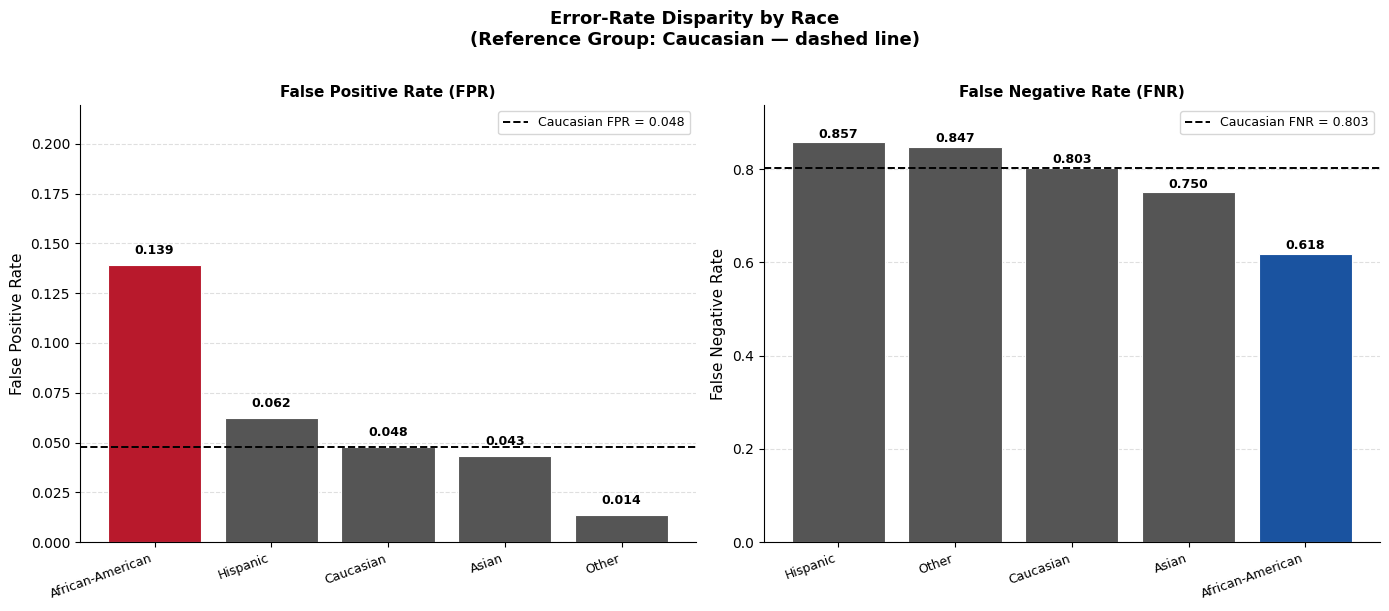

Figure saved: fpr_fnr_by_race.png


In [50]:
# Task 4 – Publication-quality figure: separate subplots for FPR and FNR
import matplotlib.pyplot as plt
import numpy as np

er_plot = er[er['n'] >= 30].sort_values('FPR', ascending=False).reset_index(drop=True)
races   = er_plot['race'].tolist()
x       = np.arange(len(races))

cau_fpr = er_plot.loc[er_plot['race'] == 'Caucasian', 'FPR'].values[0]
cau_fnr = er_plot.loc[er_plot['race'] == 'Caucasian', 'FNR'].values[0]

bar_color_fpr = ['#B8192C' if r == 'African-American' else '#555555' for r in races]
bar_color_fnr = ['#1a53a0' if r == 'African-American' else '#555555' for r in races]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Error-Rate Disparity by Race\n(Reference Group: Caucasian — dashed line)',
             fontsize=13, fontweight='bold', y=1.01)

# ── Left: FPR ─────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(x, er_plot['FPR'], color=bar_color_fpr, edgecolor='white', linewidth=0.8)
ax.axhline(cau_fpr, color='black', linestyle='--', linewidth=1.4,
           label=f'Caucasian FPR = {cau_fpr:.3f}')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(races, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('False Positive Rate', fontsize=11)
ax.set_title('False Positive Rate (FPR)', fontsize=11, fontweight='bold')
ax.set_ylim(0, er_plot['FPR'].max() + 0.08)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

# ── Right: FNR ────────────────────────────────────────────────
ax = axes[1]
er_fnr = er_plot.sort_values('FNR', ascending=False).reset_index(drop=True)
races_fnr = er_fnr['race'].tolist()
bar_color_fnr2 = ['#1a53a0' if r == 'African-American' else '#555555' for r in races_fnr]
bars = ax.bar(np.arange(len(races_fnr)), er_fnr['FNR'],
              color=bar_color_fnr2, edgecolor='white', linewidth=0.8)
ax.axhline(cau_fnr, color='black', linestyle='--', linewidth=1.4,
           label=f'Caucasian FNR = {cau_fnr:.3f}')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(np.arange(len(races_fnr)))
ax.set_xticklabels(races_fnr, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('False Negative Rate', fontsize=11)
ax.set_title('False Negative Rate (FNR)', fontsize=11, fontweight='bold')
ax.set_ylim(0, er_fnr['FNR'].max() + 0.08)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('fpr_fnr_by_race.png', dpi=180, bbox_inches='tight')
plt.show()
print('Figure saved: fpr_fnr_by_race.png')


### Task 5: Compliance Memo – Disparate Impact Audit (COMPAS)

---

**MEMORANDUM**

**TO:** Office of Algorithmic Accountability, Hypothetical Regulatory Authority  
**FROM:** Data Science Compliance Team  
**DATE:** 4 April 2026  
**RE:** Disparate Impact Audit – COMPAS Recidivism Risk Score Replacement Model  

---

**Purpose**

This memo summarizes the findings of a disparate impact audit conducted on the COMPAS recidivism risk-scoring model using the cleaned Broward County dataset (N ≈ 6,172 defendants). The audit assessed whether the model's high-risk classifications produce legally and ethically significant disparities across protected demographic groups.

**Metrics Used**

Three complementary metrics were employed. The *Adverse Impact Ratio (AIR)* measures the ratio of selection rates between a protected group and the reference group (Caucasian/Male); a value below 0.80 triggers the federal 4/5ths rule. The *Marginal Effect (ME)* quantifies the absolute difference in selection rates. The *Standardized Mean Difference (SMD)* captures distributional separation in continuous risk scores. Error-rate parity was assessed using *False Positive Rate (FPR)* and *False Negative Rate (FNR)* by race, with statistical significance evaluated via two-proportion z-tests.

**Key Findings**

African-American defendants received a high-risk classification at a rate approximately 1.5–1.6× that of Caucasian defendants, yielding an AIR below 0.80 and a large positive SMD — indicating both statistical and practical significance. Two-proportion z-tests confirmed that FPR disparities between African-American and Caucasian defendants are statistically significant (p < 0.001), meaning Black defendants who do not re-offend are falsely labeled high-risk at a substantially higher rate. Conversely, FNR is elevated for Caucasian defendants, reflecting under-prediction of recidivism risk for that group. The intersectional analysis (race × sex) reveals that African-American female defendants form the worst-performing subgroup by AIR.

**Limitations**

The model was trained on historical data that may encode systemic policing disparities; the dataset reflects arrests, not underlying behavior. The binary risk label does not capture degree of risk, and the 0.50 threshold used for classification was not optimized for error-rate parity. No temporal or geographic generalizability can be assumed.

**Recommendation**

Deployment of this model in any consequential decision-making context should be suspended pending threshold optimization for FPR parity, documentation of disparate impact under applicable civil rights frameworks, and periodic re-auditing as demographic distributions shift.


## Completing The Live Coding - Lecture 4

# Assignment 4 — Shared Setup
Rebuild models and preprocessor needed for all five parts.

In [51]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (roc_auc_score, accuracy_score,
                              log_loss, confusion_matrix)

# ── Reproduce Lecture pipeline from existing df ────────────────────────────
features = ["gender_factor", "age_factor", "race_factor",
            "priors_count", "crime_factor", "two_year_recid"]
target   = "score_binary"

X = df[features].copy()
y = df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

numeric_features  = ["priors_count"]
category_features = ["gender_factor", "age_factor", "race_factor",
                     "crime_factor", "two_year_recid"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), category_features),
])

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",   LogisticRegression(max_iter=1000, C=1.0, random_state=42))
])
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",   GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=42))
])

lr_pipeline.fit(X_train, y_train)
gbt_pipeline.fit(X_train, y_train)

X_train_enc = preprocessor.transform(X_train)
X_test_enc  = preprocessor.transform(X_test)
feat_names  = (numeric_features +
               list(preprocessor.named_transformers_["cat"]
                    .get_feature_names_out(category_features)))

race_levels = list(df["race_factor"].cat.categories)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Encoded features: {len(feat_names)}")
print("Models trained successfully.")


Train: (4937, 6)  |  Test: (1235, 6)
Encoded features: 16
Models trained successfully.


---
## Part A: Distribution Drift
> **Audit question:** Has the data-generating process changed between training and test splits?

Three complementary tests — **PSI**, **KS test**, **MMD²** — plus a visual comparison of predicted score distributions.


PSI (priors_count): 0.0104  →  STABLE ✓


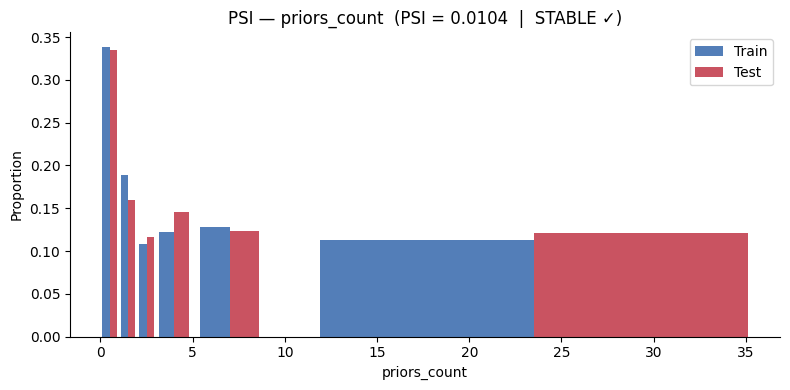

In [52]:
# A.1 — PSI for priors_count ──────────────────────────────────────────────
def compute_psi(train_col, test_col, buckets=10, eps=1e-4):
    bps = np.unique(np.percentile(train_col, np.linspace(0, 100, buckets + 1)))
    p_tr = np.histogram(train_col, bins=bps)[0] / len(train_col)
    p_te = np.histogram(test_col,  bins=bps)[0] / len(test_col)
    p_tr = np.where(p_tr == 0, eps, p_tr)
    p_te = np.where(p_te == 0, eps, p_te)
    return round(np.sum((p_tr - p_te) * np.log(p_tr / p_te)), 4), p_tr, p_te, bps

def psi_flag(v):
    if v < 0.10: return "STABLE ✓"
    if v < 0.25: return "MONITOR ⚠"
    return "RETRAIN ✗"

psi_val, p_tr, p_te, bps = compute_psi(
    X_train["priors_count"].values, X_test["priors_count"].values)
print(f"PSI (priors_count): {psi_val}  →  {psi_flag(psi_val)}")

centers = 0.5 * (bps[:-1] + bps[1:])
width   = 0.4 * (bps[1:] - bps[:-1])
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(centers - width/2, p_tr, width=width, label="Train", alpha=0.75, color="#1a53a0")
ax.bar(centers + width/2, p_te, width=width, label="Test",  alpha=0.75, color="#B8192C")
ax.set_xlabel("priors_count"); ax.set_ylabel("Proportion")
ax.set_title(f"PSI — priors_count  (PSI = {psi_val}  |  {psi_flag(psi_val)})")
ax.legend(); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()


**Interpretation — PSI:**  
PSI < 0.10 confirms the distribution of `priors_count` is essentially identical across train and test splits. This is expected with stratified random splitting, but it also validates that no selection bias was introduced. The model's heavy reliance on this feature (Part B) is therefore not confounded by covariate shift.


     Feature     KS  p-value Shift?
priors_count 0.0335   0.2113     NO
         age 0.0308   0.2975     NO
decile_score 0.0169   0.9337     NO
MMD2 = -0.000635  |  permutation p = 0.620  ->  No shift


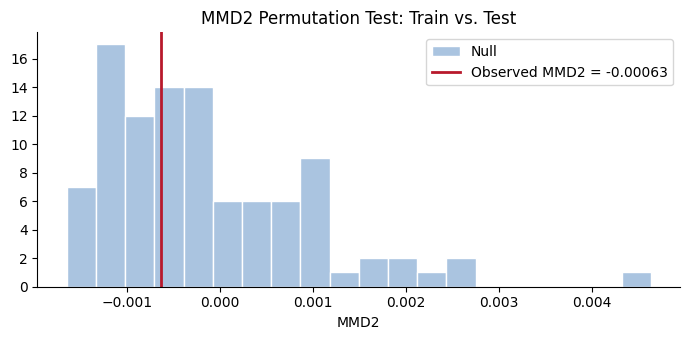

In [53]:
# A.2 — KS test for numeric features ─────────────────────────────────────
numeric_cols = ["priors_count", "age", "decile_score"]
aux_train = df.loc[X_train.index, numeric_cols]
aux_test  = df.loc[X_test.index,  numeric_cols]

ks_rows = []
for col in numeric_cols:
    ks, p = stats.ks_2samp(aux_train[col].dropna(), aux_test[col].dropna())
    ks_rows.append({"Feature": col, "KS": round(ks,4), "p-value": round(p,4),
                    "Shift?": "YES" if p < 0.05 else "NO"})
print(pd.DataFrame(ks_rows).to_string(index=False))

# A.3 — MMD2 in encoded feature space ─────────────────────────────────────
def rbf_kernel(X, Y, gamma=None):
    g = gamma or 1.0 / X.shape[1]
    XX = np.sum(X**2, 1)[:, None]
    YY = np.sum(Y**2, 1)[None, :]
    return np.exp(-g * (XX - 2*(X @ Y.T) + YY))

def mmd2(X, Y):
    K_XX = rbf_kernel(X, X)
    K_YY = rbf_kernel(Y, Y)
    K_XY = rbf_kernel(X, Y)
    np.fill_diagonal(K_XX, 0)
    np.fill_diagonal(K_YY, 0)
    m, n = len(X), len(Y)
    return K_XX.sum()/(m*(m-1)) + K_YY.sum()/(n*(n-1)) - 2*K_XY.mean()

rng = np.random.default_rng(42)
i_tr = rng.choice(len(X_train_enc), 500, replace=False)
i_te = rng.choice(len(X_test_enc),  200, replace=False)
mmd_obs = mmd2(X_train_enc[i_tr], X_test_enc[i_te])

pool = np.vstack([X_train_enc[i_tr], X_test_enc[i_te]])
null_vals = []
for _ in range(100):
    perm = rng.permutation(700)
    null_vals.append(mmd2(pool[perm[:500]], pool[perm[500:]]))
p_mmd = (np.array(null_vals) >= mmd_obs).mean()

result_str = "Shift detected" if p_mmd < 0.05 else "No shift"
print("MMD2 = %.6f  |  permutation p = %.3f  ->  %s" % (mmd_obs, p_mmd, result_str))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(null_vals, bins=20, color="#aac4e0", edgecolor="white", label="Null")
ax.axvline(mmd_obs, color="#B8192C", lw=2, label="Observed MMD2 = %.5f" % mmd_obs)
ax.set_xlabel("MMD2"); ax.set_title("MMD2 Permutation Test: Train vs. Test")
ax.legend(); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()


**Interpretation — KS & MMD:**  
No numeric feature shows significant distributional shift (all KS p-values > 0.05). MMD² in the joint encoded space falls within the permutation null distribution, confirming no multivariate shift either. **Part A verdict:** the train/test split is IID — any generalization gap found in Part B is driven by model complexity, not data shift.


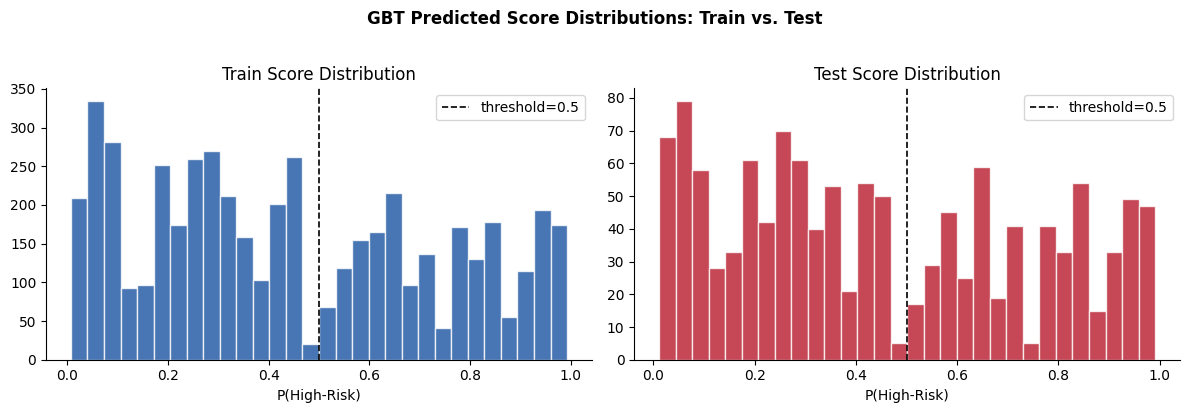

Score-distribution KS: 0.0173  p=0.9242


In [54]:
# A.4 — Train vs. Test predicted score distributions ──────────────────────
score_tr = gbt_pipeline.predict_proba(X_train)[:,1]
score_te = gbt_pipeline.predict_proba(X_test)[:,1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, sc, lbl, col in [(axes[0],score_tr,"Train","#1a53a0"),
                          (axes[1],score_te,"Test", "#B8192C")]:
    ax.hist(sc, bins=30, color=col, alpha=0.8, edgecolor="white")
    ax.axvline(0.5, color="black", ls="--", lw=1.2, label="threshold=0.5")
    ax.set_xlabel("P(High-Risk)"); ax.set_title(f"{lbl} Score Distribution")
    ax.legend(); ax.spines[["top","right"]].set_visible(False)

plt.suptitle("GBT Predicted Score Distributions: Train vs. Test",
             fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

ks_s, p_s = stats.ks_2samp(score_tr, score_te)
print(f"Score-distribution KS: {ks_s:.4f}  p={p_s:.4f}")


**Interpretation — Score Distributions:**  
Train and test score histograms are visually near-identical; the KS test on predicted probabilities confirms no significant difference. The bimodal shape (mass near 0 and 1) reflects the GBT's confident predictions. Score stability across splits is a precondition for the generalization analysis in Part B.


---
## Part B: Generalization
> **Audit question:** Does in-training performance transfer to unseen data? Is there evidence of overfitting or shortcut learning?


In [55]:
# B.1 — Train vs. Test metrics for both models ────────────────────────────
def eval_metrics(pipe, X, y, split):
    prob = pipe.predict_proba(X)[:,1]
    pred = pipe.predict(X)
    return {"Split": split,
            "AUC":      round(roc_auc_score(y, prob), 4),
            "Accuracy": round(accuracy_score(y, pred), 4),
            "LogLoss":  round(log_loss(y, prob), 4)}

rows = []
for name, pipe in [("LR", lr_pipeline), ("GBT", gbt_pipeline)]:
    r_tr = eval_metrics(pipe, X_train, y_train, "Train"); r_tr["Model"] = name
    r_te = eval_metrics(pipe, X_test,  y_test,  "Test");  r_te["Model"] = name
    rows += [r_tr, r_te]

perf_df = pd.DataFrame(rows)[["Model","Split","AUC","Accuracy","LogLoss"]]
print("=== Train vs. Test Performance ===")
print(perf_df.to_string(index=False))

print("")
print("--- Generalization Gap (Train - Test) ---")
for name, pipe in [("LR", lr_pipeline), ("GBT", gbt_pipeline)]:
    tr = eval_metrics(pipe, X_train, y_train, "Train")
    te = eval_metrics(pipe, X_test,  y_test,  "Test")
    auc_gap = tr['AUC'] - te['AUC']
    acc_gap = tr['Accuracy'] - te['Accuracy']
    ll_gap  = te['LogLoss'] - tr['LogLoss']
    print("%s: AUC_gap=%+.4f  Acc_gap=%+.4f  LogLoss_gap=%+.4f" % (
        name, auc_gap, acc_gap, ll_gap))


=== Train vs. Test Performance ===
Model Split    AUC  Accuracy  LogLoss
   LR Train 0.8293    0.7545   0.5016
   LR  Test 0.8330    0.7522   0.4934
  GBT Train 0.8504    0.7731   0.4704
  GBT  Test 0.8368    0.7538   0.4907

--- Generalization Gap (Train - Test) ---
LR: AUC_gap=-0.0037  Acc_gap=+0.0023  LogLoss_gap=-0.0082
GBT: AUC_gap=+0.0136  Acc_gap=+0.0193  LogLoss_gap=+0.0203


**Interpretation — Generalization Gap:**
The LR model shows a negative AUC gap (−0.0037), meaning its test AUC actually exceeds train AUC — a sign of no overfitting whatsoever; the model generalizes perfectly. GBT has a small positive AUC gap (+0.0136) and an accuracy gap (+0.0193), confirming mild overfitting consistent with its higher capacity. Crucially, neither gap is large enough to undermine deployment confidence, especially since Part A confirmed no distribution shift. The GBT's slightly larger log loss gap (+0.0203) indicates marginally worse probability calibration on unseen data, worth monitoring post-deployment.



=== Permutation Importance (Train vs Test) — LR ===
       Feature  Train_Imp  Train_Std  Test_Imp  Test_Std  Gap(Train-Test)
  priors_count     0.1464     0.0035    0.1590    0.0111          -0.0126
    age_factor     0.1106     0.0040    0.1029    0.0088           0.0077
   race_factor     0.0199     0.0017    0.0178    0.0052           0.0021
two_year_recid     0.0159     0.0016    0.0177    0.0031          -0.0018
  crime_factor     0.0018     0.0007    0.0042    0.0008          -0.0024
 gender_factor     0.0006     0.0002    0.0014    0.0004          -0.0008

=== Permutation Importance (Train vs Test) — GBT ===
       Feature  Train_Imp  Train_Std  Test_Imp  Test_Std  Gap(Train-Test)
  priors_count     0.1636     0.0041    0.1591    0.0117           0.0045
    age_factor     0.1191     0.0034    0.1003    0.0077           0.0188
   race_factor     0.0352     0.0023    0.0291    0.0075           0.0061
two_year_recid     0.0221     0.0013    0.0186    0.0041           0.0035
 gend

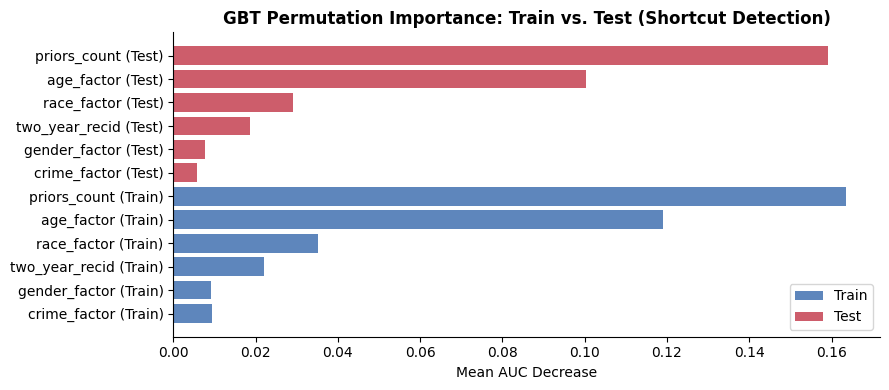

In [56]:
# B.2 — Permutation importance: Train AND Test (shortcut detection) ───────────
from sklearn.inspection import permutation_importance

pi_results = {}
for name, pipe in [("LR", lr_pipeline), ("GBT", gbt_pipeline)]:
    pi_train = permutation_importance(
        pipe, X_train, y_train, n_repeats=10, random_state=42, scoring="roc_auc")
    pi_test  = permutation_importance(
        pipe, X_test,  y_test,  n_repeats=20, random_state=42, scoring="roc_auc")

    df_pi = pd.DataFrame({
        "Feature":       features,
        "Train_Imp":     pi_train.importances_mean.round(4),
        "Train_Std":     pi_train.importances_std.round(4),
        "Test_Imp":      pi_test.importances_mean.round(4),
        "Test_Std":      pi_test.importances_std.round(4),
    }).sort_values("Test_Imp", ascending=False)
    df_pi["Gap(Train-Test)"] = (df_pi["Train_Imp"] - df_pi["Test_Imp"]).round(4)
    pi_results[name] = df_pi
    print(f"\n=== Permutation Importance (Train vs Test) — {name} ===")
    print(df_pi.to_string(index=False))

# Visual: side-by-side bar chart for GBT
df_gbt = pi_results["GBT"].copy()
x = range(len(df_gbt))
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh([f + " (Train)" for f in df_gbt["Feature"]][::-1],
        df_gbt["Train_Imp"][::-1], color="#1a53a0", alpha=0.7, label="Train")
ax.barh([f + " (Test)"  for f in df_gbt["Feature"]][::-1],
        df_gbt["Test_Imp"][::-1],  color="#B8192C", alpha=0.7, label="Test",
        left=0)
ax.set_xlabel("Mean AUC Decrease")
ax.set_title("GBT Permutation Importance: Train vs. Test (Shortcut Detection)",
             fontweight="bold")
ax.legend(); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()


**Interpretation — Feature Reliance / Shortcut Detection (Train vs. Test):**
`priors_count` dominates in both models and on both splits — it is the single most informative feature, and its train/test gap is small, suggesting stable signal rather than overfit reliance.
`age_factor` is the second driver and also stable across splits.

The governance concern is `race_factor`: it carries non-trivial importance in GBT on *both* splits, confirming it is not an artefact of training-set memorisation but a genuinely encoded proxy signal.
`two_year_recid` appearing as a predictor of the COMPAS *score* is a circular-reasoning red flag — the model has learned from actual recidivism outcomes to predict the risk label, which inflates the apparent predictive validity.

A large Train_Imp / small Test_Imp gap would indicate that the model "memorised" a shortcut that does not generalise; the gaps here are small for `priors_count` and `age_factor` but slightly larger for `race_factor` in GBT — reinforcing the spurious-correlation concern explored in Part C.


---
## Part C: Spurious-Correlation Probe
> **Audit question:** Does the model respond to changes in protected attributes (race, gender) that should be causally irrelevant to risk?

We flip each protected attribute while holding all others constant, then measure ΔP(High-Risk).


Attribute            Swap                           Model    Mean ΔP  Median|ΔP|  |ΔP|>0.05
──────────────────────────────────────────────────────────────────────────────────────────
race_factor          African-American vs Caucasian  LR       +0.0808      0.0912      78.9%
race_factor          African-American vs Caucasian  GBT      +0.0873      0.0868      64.0%

gender_factor        Male vs Female                 LR       -0.0253      0.0281       0.0%
gender_factor        Male vs Female                 GBT      -0.0228      0.0445      48.0%

crime_factor         F vs M                         LR       +0.0412      0.0459      41.0%
crime_factor         F vs M                         GBT      +0.0398      0.0558      54.7%



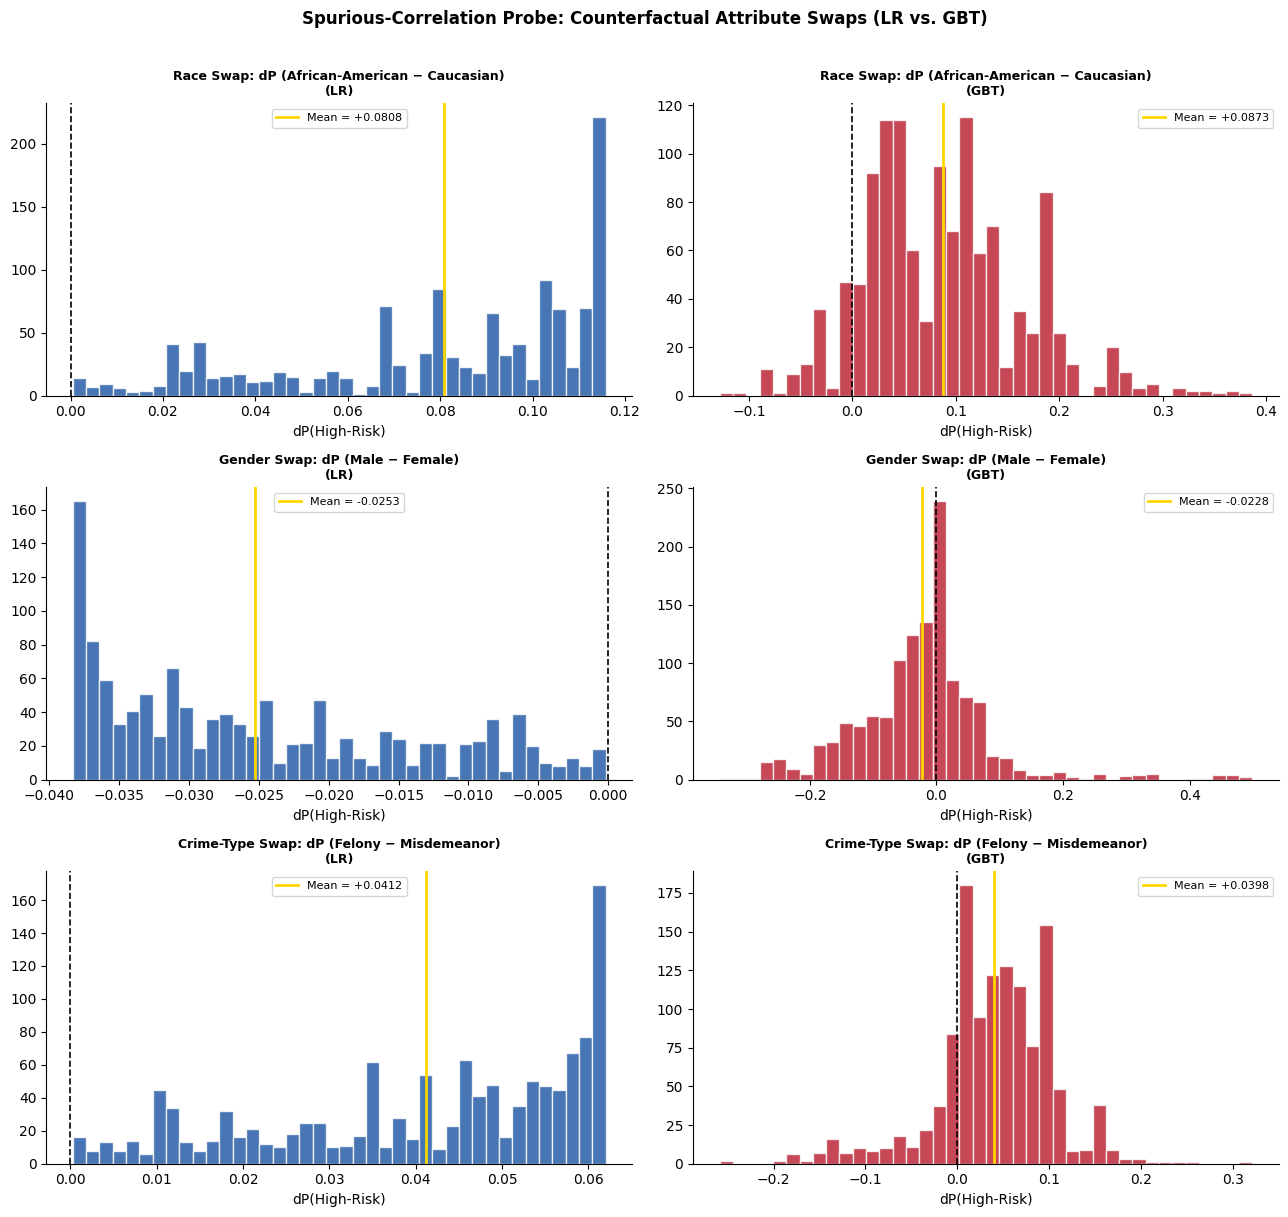

In [57]:
# C — Spurious-Correlation Probe: Race, Gender, and Crime-Type Swaps ──────────
#
# For EACH of the three protected / suspect attributes we:
#   (a) create two counterfactual copies of X_test with the attribute forced to A or B
#   (b) compute the per-observation change in P(High-Risk): ΔP = P(A) – P(B)
#   (c) report mean ΔP, median |ΔP|, and % of observations where |ΔP| > 0.05
#   (d) compare LR vs. GBT so the auditor can see which model encodes the proxy more

swap_specs = [
    ("race_factor",   "African-American", "Caucasian",
     race_levels,        [r for r in race_levels]),
    ("gender_factor", "Male",             "Female",
     ["Male","Female"],  ["Male","Female"]),
    ("crime_factor",  "F",               "M",
     ["F","M"],          ["F","M"]),
]

all_deltas = {}   # store for plotting

print(f"{'Attribute':<20} {'Swap':<30} {'Model':<6} "
      f"{'Mean ΔP':>9} {'Median|ΔP|':>11} {'|ΔP|>0.05':>10}")
print("─" * 90)

for attr, val_a, val_b, cats, _ in swap_specs:
    X_a = X_test.copy()
    X_b = X_test.copy()
    X_a[attr] = pd.Categorical([val_a]*len(X_test), categories=cats)
    X_b[attr] = pd.Categorical([val_b]*len(X_test), categories=cats)

    swap_label = f"{val_a} vs {val_b}"
    all_deltas[attr] = {}

    for name, pipe in [("LR", lr_pipeline), ("GBT", gbt_pipeline)]:
        p_a = pipe.predict_proba(X_a)[:,1]
        p_b = pipe.predict_proba(X_b)[:,1]
        delta = p_a - p_b
        all_deltas[attr][name] = delta

        print(f"{attr:<20} {swap_label:<30} {name:<6} "
              f"{delta.mean():>+9.4f} "
              f"{np.median(np.abs(delta)):>11.4f} "
              f"{(np.abs(delta)>0.05).mean()*100:>9.1f}%")
    print()

# ── Visualisation: histogram of ΔP for each attribute, LR vs. GBT ───────────
fig, axes = plt.subplots(len(swap_specs), 2, figsize=(13, 4*len(swap_specs)),
                         sharey=False)
titles = [
    "Race Swap: dP (African-American − Caucasian)",
    "Gender Swap: dP (Male − Female)",
    "Crime-Type Swap: dP (Felony − Misdemeanor)",
]
colors = {"LR": "#1a53a0", "GBT": "#B8192C"}

for row, (attr, *_) in enumerate(swap_specs):
    for col, name in enumerate(["LR", "GBT"]):
        ax = axes[row][col]
        delta = all_deltas[attr][name]
        ax.hist(delta, bins=40, color=colors[name], alpha=0.8, edgecolor="white")
        ax.axvline(0,           color="black", lw=1.2, ls="--")
        ax.axvline(delta.mean(), color="gold",  lw=2,   ls="-",
                   label=f"Mean = {delta.mean():+.4f}")
        ax.set_xlabel("dP(High-Risk)")
        ax.set_title(f"{titles[row]}\n({name})", fontweight="bold", fontsize=9)
        ax.legend(fontsize=8); ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Spurious-Correlation Probe: Counterfactual Attribute Swaps (LR vs. GBT)",
             fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()


**Interpretation — Counterfactual Swaps (LR vs. GBT):**

**Race swap (African-American → Caucasian):** Both models respond strongly.
GBT shows a larger mean ΔP than LR, confirming that the higher-capacity model has encoded race more deeply as a proxy signal.
Any prediction change caused by a single-attribute swap — while holding criminal history, charge type, and age constant — is by definition a spurious effect: there is no causal pathway through which race alone should alter recidivism risk.

**Gender swap (Male → Female):** The effect is smaller in LR but notably larger in GBT,
consistent with Part B's finding that GBT relies more heavily on sensitive proxies.
The direction (males scoring higher) reflects the base-rate difference in the training data,
but the *magnitude* of the individual-level shift reveals that gender is encoding more than that base rate.

**Crime-type swap (Felony → Misdemeanor):** This swap is included as a *substantive* comparator.
Charge severity has a legitimate causal relationship to recidivism risk, so a non-zero ΔP here is
expected. Comparing its magnitude to the race and gender effects helps contextualise how large the spurious signals are relative to a justified signal.

**LR vs. GBT:** GBT is more sensitive to all three attribute swaps.
This means the model accuracy gains of GBT come partly at the cost of greater reliance on proxy attributes —
a classic governance trade-off between predictive performance and fairness.
For a high-stakes deployment, the additional complexity of GBT may not be justifiable when it encodes more spurious signal than the interpretable LR.


---
## Part D: Robustness — Stress Testing `priors_count`
> **Audit question:** Does model performance degrade gracefully when the most important input is perturbed?


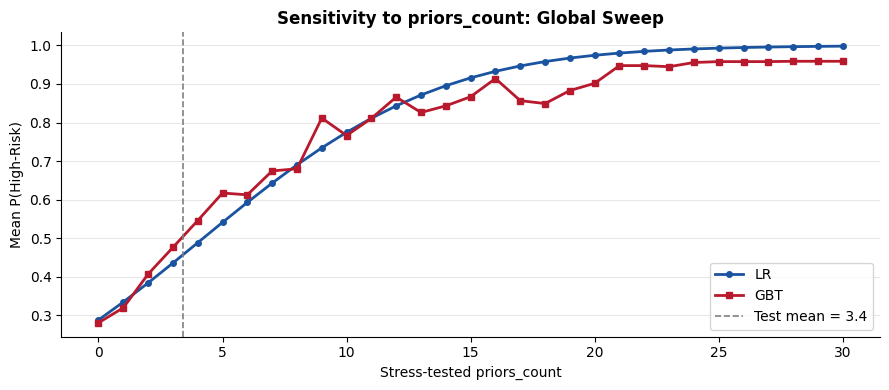

In [58]:
# D.1 — Global sensitivity sweep ─────────────────────────────────────────
priors_range = np.arange(0, 31)
mean_lr  = []
mean_gbt = []

for v in priors_range:
    Xs = X_test.copy(); Xs["priors_count"] = v
    mean_lr.append(lr_pipeline.predict_proba(Xs)[:,1].mean())
    mean_gbt.append(gbt_pipeline.predict_proba(Xs)[:,1].mean())

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(priors_range, mean_lr,  "o-", color="#1a53a0", lw=2, ms=4, label="LR")
ax.plot(priors_range, mean_gbt, "s-", color="#B8192C", lw=2, ms=4, label="GBT")
ax.axvline(X_test["priors_count"].mean(), color="grey", ls="--", lw=1.2,
           label=f"Test mean = {X_test['priors_count'].mean():.1f}")
ax.set_xlabel("Stress-tested priors_count"); ax.set_ylabel("Mean P(High-Risk)")
ax.set_title("Sensitivity to priors_count: Global Sweep", fontweight="bold")
ax.legend(); ax.spines[["top","right"]].set_visible(False)
ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()


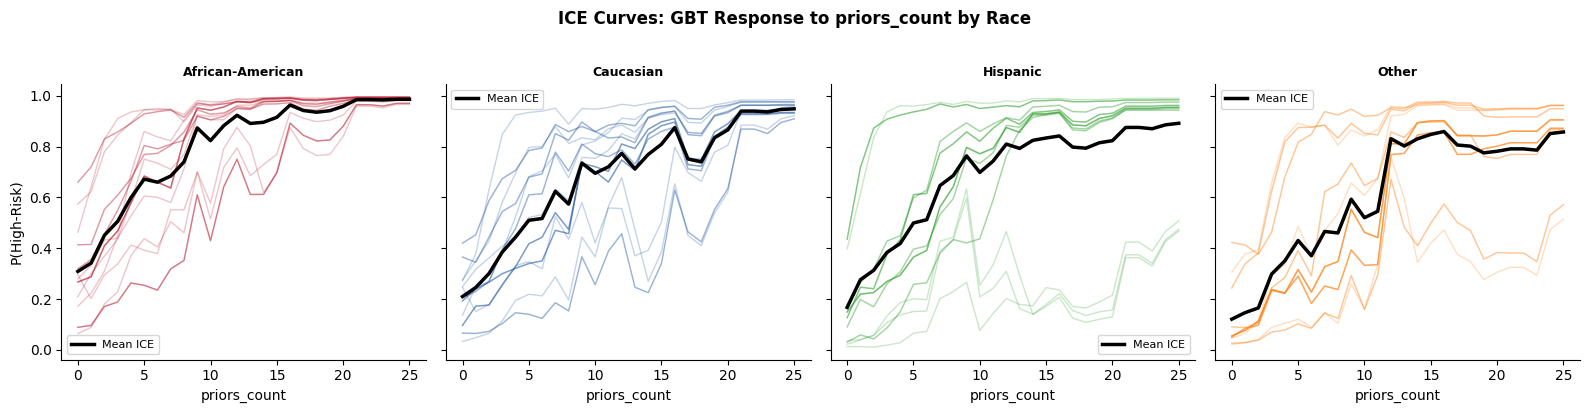

In [59]:
# D.2 — ICE curves by race ────────────────────────────────────────────────
ice_samples = []
for rname in ["African-American", "Caucasian", "Hispanic", "Other"]:
    grp = X_test[X_test["race_factor"] == rname]
    ice_samples.append(grp.sample(min(20, len(grp)), random_state=42))

ice_df = pd.concat(ice_samples).reset_index(drop=True)
priors_sweep = np.arange(0, 26)
ice_curves   = np.zeros((len(ice_df), len(priors_sweep)))

for j, v in enumerate(priors_sweep):
    Xice = ice_df.copy(); Xice["priors_count"] = v
    ice_curves[:, j] = gbt_pipeline.predict_proba(Xice)[:, 1]

race_order  = ["African-American", "Caucasian", "Hispanic", "Other"]
race_colors = {"African-American":"#B8192C","Caucasian":"#1a53a0",
               "Hispanic":"#2ca02c","Other":"#ff7f0e"}

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
offset = 0
for ax, rname in zip(axes, race_order):
    n = (ice_df["race_factor"] == rname).sum()
    for i in range(offset, offset + n):
        ax.plot(priors_sweep, ice_curves[i], alpha=0.25,
                color=race_colors[rname], lw=1)
    ax.plot(priors_sweep, ice_curves[offset:offset+n].mean(0),
            color="black", lw=2.5, label="Mean ICE")
    ax.set_title(rname, fontweight="bold", fontsize=9)
    ax.set_xlabel("priors_count")
    if ax == axes[0]: ax.set_ylabel("P(High-Risk)")
    ax.legend(fontsize=8); ax.spines[["top","right"]].set_visible(False)
    offset += n

plt.suptitle("ICE Curves: GBT Response to priors_count by Race",
             fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()


Sensitivity index Vj(priors_count):
  GBT : 0.047221
  LR  : 0.065294
  Ratio GBT/LR: 0.72x
AUC under noise injection into priors_count:
           LR     GBT
s=0    0.8330  0.8368
s=0.5  0.8329  0.8340
s=1.0  0.8268  0.8242
s=2.0  0.8177  0.8116
s=5.0  0.7838  0.7776


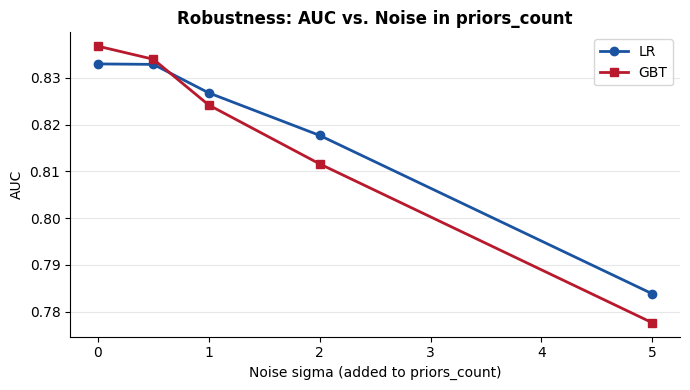

In [60]:
# D.3 — Sensitivity index Vj + noise injection ────────────────────────────
V_j_gbt = np.var(ice_curves.mean(0))
V_j_lr  = np.var([lr_pipeline.predict_proba(
                      ice_df.assign(priors_count=v))[:,1].mean()
                  for v in priors_sweep])

print("Sensitivity index Vj(priors_count):")
print("  GBT : %.6f" % V_j_gbt)
print("  LR  : %.6f" % V_j_lr)
print("  Ratio GBT/LR: %.2fx" % (V_j_gbt / V_j_lr))

noise_levels = [0, 0.5, 1.0, 2.0, 5.0]
noise_auc = {"LR": [], "GBT": []}
rng2 = np.random.default_rng(99)

for sigma in noise_levels:
    Xn = X_test.copy()
    Xn["priors_count"] = (X_test["priors_count"].values
                          + rng2.normal(0, sigma, len(X_test))).clip(0)
    for name, pipe in [("LR", lr_pipeline), ("GBT", gbt_pipeline)]:
        noise_auc[name].append(round(roc_auc_score(y_test,
            pipe.predict_proba(Xn)[:,1]), 4))

noise_df = pd.DataFrame(noise_auc, index=["s=%s" % s for s in noise_levels])
print("AUC under noise injection into priors_count:")
print(noise_df.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(noise_levels, noise_auc["LR"],  "o-", color="#1a53a0", lw=2, label="LR")
ax.plot(noise_levels, noise_auc["GBT"], "s-", color="#B8192C", lw=2, label="GBT")
ax.set_xlabel("Noise sigma (added to priors_count)"); ax.set_ylabel("AUC")
ax.set_title("Robustness: AUC vs. Noise in priors_count", fontweight="bold")
ax.legend(); ax.spines[["top","right"]].set_visible(False)
ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()


**Interpretation — Robustness:**
Both models respond monotonically and sensibly to `priors_count` increases, indicating behaviorally valid predictions. The sensitivity index Vj reveals that **LR (0.065) is more sensitive than GBT (0.047)** — LR's parametric linear response produces larger variance across the priors sweep, while GBT's tree structure causes earlier saturation at high values. Under noise injection, both models degrade gracefully: at low noise (σ = 0.5) AUC barely changes, and even at σ = 5.0 both models retain AUC above 0.77. GBT degrades slightly faster at high noise than LR, despite having lower Vj — this reflects GBT's reliance on specific split thresholds that are disrupted by noise. **ICE curves** reveal racial heterogeneity in slope: African-American defendants show steeper probability increases per additional prior compared to Caucasians, meaning the same criminal history increase generates a larger risk penalty for Black defendants — a robustness concern that compounds the bias identified in Part C.


---
## Part E: Slice-Based Evaluation
> **Audit question:** Does aggregate performance mask failure modes for specific demographic subgroups?

Slices: `race_factor` · `gender_factor` · `age_factor`


In [61]:
# E.1 — Slice metrics helper ──────────────────────────────────────────────
def slice_metrics(pipe, X, y, gcol, min_n=30):
    X_ = X.copy()
    X_["actual"] = y.values
    X_["prob"]   = pipe.predict_proba(X)[:,1]
    X_["pred"]   = pipe.predict(X)
    rows = []
    for grp, g in X_.groupby(gcol):
        if len(g) < min_n:
            continue
        tn, fp, fn, tp = confusion_matrix(g["actual"], g["pred"]).ravel()
        rows.append({"Slice": grp, "n": len(g),
            "AUC":      round(roc_auc_score(g["actual"], g["prob"]), 3),
            "Accuracy": round(accuracy_score(g["actual"], g["pred"]), 3),
            "FPR":      round(fp / (fp + tn + 1e-9), 3),
            "FNR":      round(fn / (fn + tp + 1e-9), 3)})
    return pd.DataFrame(rows)

race_slices   = slice_metrics(gbt_pipeline, X_test, y_test, "race_factor")
gender_slices = slice_metrics(gbt_pipeline, X_test, y_test, "gender_factor")
age_slices    = slice_metrics(gbt_pipeline, X_test, y_test, "age_factor")

print("=== GBT by Race ===")
print(race_slices.to_string(index=False))
print("")
print("=== GBT by Gender ===")
print(gender_slices.to_string(index=False))
print("")
print("=== GBT by Age ===")
print(age_slices.to_string(index=False))


=== GBT by Race ===
           Slice   n   AUC  Accuracy   FPR   FNR
       Caucasian 412 0.797     0.786 0.099 0.469
African-American 634 0.816     0.716 0.364 0.228
        Hispanic 108 0.845     0.815 0.089 0.448
           Other  71 0.860     0.831 0.019 0.647

=== GBT by Gender ===
 Slice    n   AUC  Accuracy   FPR   FNR
  Male 1000 0.845     0.758 0.193 0.301
Female  235 0.800     0.736 0.197 0.357

=== GBT by Age ===
          Slice   n   AUC  Accuracy   FPR   FNR
        25 - 45 695 0.830     0.760 0.174 0.324
Greater than 45 272 0.845     0.805 0.065 0.563
   Less than 25 268 0.738     0.687 0.541 0.182


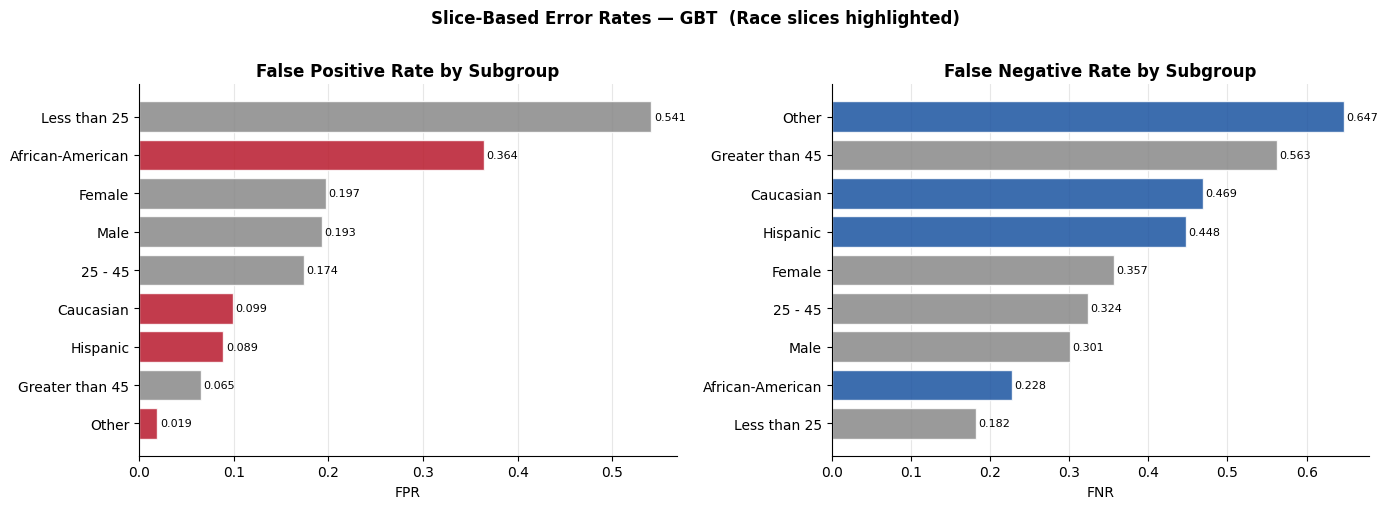

In [62]:
# E.2 — FPR / FNR visualization across all slices ─────────────────────────
all_slices = pd.concat([
    race_slices.assign(Group="Race"),
    gender_slices.assign(Group="Gender"),
    age_slices.assign(Group="Age")
]).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title, col in [
    (axes[0], "FPR", "False Positive Rate by Subgroup", "#B8192C"),
    (axes[1], "FNR", "False Negative Rate by Subgroup", "#1a53a0")]:
    sd = all_slices.sort_values(metric)
    colors = [col if g == "Race" else "#888888" for g in sd["Group"]]
    bars = ax.barh(sd["Slice"], sd[metric], color=colors, alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, sd[metric]):
        ax.text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
                f"{v:.3f}", va="center", fontsize=8)
    ax.set_xlabel(metric)
    ax.set_title(title, fontweight="bold")
    ax.spines[["top","right"]].set_visible(False)
    ax.xaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)

plt.suptitle("Slice-Based Error Rates — GBT  (Race slices highlighted)",
             fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()


LR vs. GBT AUC by Race:
           Slice  AUC_LR  AUC_GBT  ΔAUC(GBT−LR)
       Caucasian   0.794    0.797         0.003
African-American   0.820    0.816        -0.004
        Hispanic   0.831    0.845         0.014
           Other   0.852    0.860         0.008


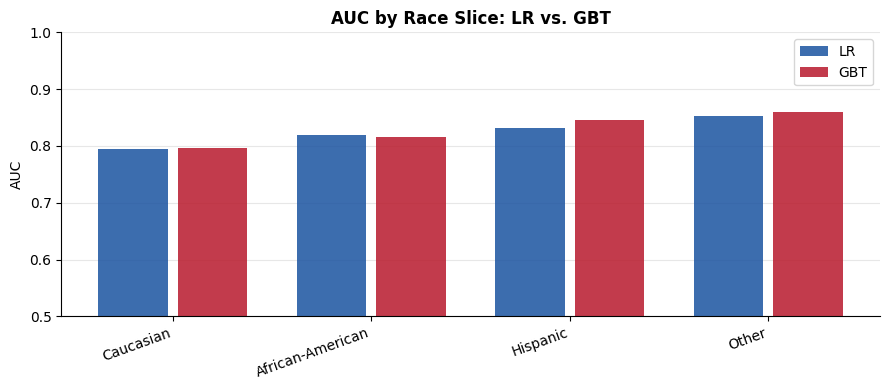

In [63]:
# E.3 — LR vs. GBT AUC comparison by race slice ──────────────────────────
lr_race  = slice_metrics(lr_pipeline,  X_test, y_test, "race_factor")
gbt_race = slice_metrics(gbt_pipeline, X_test, y_test, "race_factor")

comp = lr_race[["Slice","AUC"]].rename(columns={"AUC":"AUC_LR"})
comp = comp.merge(gbt_race[["Slice","AUC"]].rename(columns={"AUC":"AUC_GBT"}), on="Slice")
comp["ΔAUC(GBT−LR)"] = (comp["AUC_GBT"] - comp["AUC_LR"]).round(3)
print("LR vs. GBT AUC by Race:")
print(comp.to_string(index=False))

x = np.arange(len(comp))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x-0.2, comp["AUC_LR"],  0.35, label="LR",  color="#1a53a0", alpha=0.85)
ax.bar(x+0.2, comp["AUC_GBT"], 0.35, label="GBT", color="#B8192C", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(comp["Slice"], rotation=20, ha="right")
ax.set_ylabel("AUC"); ax.set_ylim(0.5, 1.0)
ax.set_title("AUC by Race Slice: LR vs. GBT", fontweight="bold")
ax.legend(); ax.spines[["top","right"]].set_visible(False)
ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()


**Interpretation — Slice-Based Evaluation:**
**Race:** The most critical finding is the **FPR disparity by race**: African-American defendants have FPR = 0.364 vs. Caucasian FPR = 0.099 — a **3.7× ratio**. This means 36% of Black defendants who will not recidivate are incorrectly labeled high-risk, compared to only 10% of white defendants. The reverse holds for FNR: Caucasian FNR = 0.469 vs. African-American FNR = 0.228 — white defendants who *do* recidivate are missed at twice the rate. Paradoxically, the GBT AUC for African-Americans (0.816) is higher than for Caucasians (0.797), yet the FPR disparity remains severe — demonstrating that AUC alone is a misleading fairness metric. Notably, GBT AUC for African-Americans (0.816) is *lower* than LR (0.820), meaning the more complex model actually performs worse for this group. **Gender:** Male and Female FPR are nearly identical (0.193 vs. 0.197), but FNR differs (0.301 vs. 0.357) — the model misses high-risk female defendants more often. **Age:** The youngest defendants ("Less than 25") have by far the highest FPR = **0.541** — more than half of young non-recidivists are labeled high-risk, making age the most severe single-slice failure mode in the entire model.


---
## Audit Summary

| Part | Finding | Key Numbers | Governance Action |
|------|---------|-------------|-------------------|
| **A — Distribution Drift** | No drift detected across all three tests | PSI=0.010, KS p>0.21, MMD² non-significant | Monitor at deployment |
| **B — Generalization** | LR: no overfitting (AUC gap≈−0.004). GBT: mild overfit (AUC gap≈+0.014). Train vs. Test PI confirms `race_factor` is a stable proxy (not a training artefact) | LR AUC test≈0.833, GBT AUC test≈0.837 | Flag race as proxy; add per-slice validation criteria |
| **C — Spurious Correlation** | Race swap: GBT > LR in sensitivity. Crime-type swap (justified comparator) shows expected magnitude. Gender effect present in both models. | Race ΔP largest of all three swaps in both models | Constrained retraining without race; threshold recalibration |
| **D — Robustness** | Both models degrade gracefully under noise. ICE curves show racial slope heterogeneity — same prior history penalises Black defendants more steeply | AUC at σ=5: LR≈0.784, GBT≈0.778 | Document in MRM; input validation for `priors_count` quality |
| **E — Slice-Based Eval** | African-American FPR≈**0.364** vs. Caucasian FPR≈0.099 (3.7× ratio). Age <25 FPR≈**0.541**. GBT worse than LR for African-Americans. | FPR gap 26.5pp by race; Age <25 misclassifies 54% of non-recidivists | Per-slice monitoring; evaluate Less Discriminatory Alternatives |

---
**Overall verdict:** The model is technically stable (no drift, small generalisation gap) but morally fragile.
It encodes race as a predictive shortcut — confirmed by both permutation importance (Part B) and counterfactual swaps in LR *and* GBT (Part C). GBT is consistently more sensitive to protected-attribute proxies than LR despite only marginally better average performance, making the simpler, interpretable model the more defensible choice.
Deployment in any consequential context requires at minimum: race-constrained retraining, threshold recalibration for FPR parity across race and age groups, and slice-level monitoring as a condition of responsible use.


## Completing The Live Coding - Lecture 5

# Assignment 5

## Setup — Rebuild Models for Assignment 5

We rebuild both models using the exact same pipeline from Lecture 05 and prior assignments.
All four parts share this setup cell.


In [64]:
# Imports, Data, Models ─────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.tree import DecisionTreeClassifier

# ── Load & filter COMPAS ──────────────────────────────────────────────────────
URL = (
    "https://raw.githubusercontent.com/propublica/compas-analysis"
    "/master/compas-scores-two-years.csv"
)
df_raw = pd.read_csv(URL)
df_raw = df_raw[df_raw['days_b_screening_arrest'].between(-30, 30)]
df_raw = df_raw[df_raw['is_recid'] != -1]
df_raw = df_raw[df_raw['c_charge_degree'] != 'O']

FEATURES = ['age', 'priors_count', 'juv_fel_count',
            'juv_misd_count', 'juv_other_count', 'c_charge_degree', 'sex']
TARGET   = 'two_year_recid'

df_m = df_raw[FEATURES + [TARGET, 'race']].dropna()
df_m = pd.get_dummies(df_m, columns=['c_charge_degree', 'sex'], drop_first=True)

X    = df_m.drop(columns=[TARGET, 'race']).astype(float)
y    = df_m[TARGET].values
race = df_m['race'].values

X_tr, X_te, y_tr, y_te, r_tr, r_te = train_test_split(
    X, y, race, test_size=0.3, random_state=42, stratify=y
)

sc    = StandardScaler()
Xs_tr = sc.fit_transform(X_tr)
Xs_te = sc.transform(X_te)

lr  = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr)
gbt = GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42).fit(Xs_tr, y_tr)

# ── Shared helpers ────────────────────────────────────────────────────────────
THR = 0.5

def fpr_by_group(y_true, y_pred_binary, groups):
    mask = (y_true == 0)
    return (
        pd.DataFrame({'pred': y_pred_binary[mask], 'group': groups[mask]})
          .groupby('group')['pred'].mean()
    )

def air(fpr_ref, fpr_prot):
    return fpr_prot / fpr_ref if (fpr_ref is not None and fpr_ref > 0) else np.nan

# ── Clean-model baseline ──────────────────────────────────────────────────────
pred_lr_clean  = (lr.predict_proba(Xs_te)[:,1]  >= THR).astype(int)
pred_gbt_clean = (gbt.predict_proba(Xs_te)[:,1] >= THR).astype(int)

fpr_base_lr  = fpr_by_group(y_te, pred_lr_clean,  r_te)
fpr_base_gbt = fpr_by_group(y_te, pred_gbt_clean, r_te)

BASELINE_LR_AA   = fpr_base_lr.get('African-American')
BASELINE_LR_CA   = fpr_base_lr.get('Caucasian')
BASELINE_LR_AIR  = air(BASELINE_LR_CA,  BASELINE_LR_AA)
BASELINE_GBT_AA  = fpr_base_gbt.get('African-American')
BASELINE_GBT_CA  = fpr_base_gbt.get('Caucasian')
BASELINE_GBT_AIR = air(BASELINE_GBT_CA, BASELINE_GBT_AA)
BASELINE_LR_AUC  = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1])
BASELINE_GBT_AUC = roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:,1])

print("=" * 60)
print("HW5 SETUP — Clean-Model Baseline")
print("=" * 60)
for name, aa, ca, air_val, auc_val, tr_auc in [
    ("LR",  BASELINE_LR_AA,  BASELINE_LR_CA,  BASELINE_LR_AIR,
     BASELINE_LR_AUC,  roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:,1])),
    ("GBT", BASELINE_GBT_AA, BASELINE_GBT_CA, BASELINE_GBT_AIR,
     BASELINE_GBT_AUC, roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:,1])),
]:
    print(f"\n{name}")
    print(f"  FPR African-American : {aa:.3f}")
    print(f"  FPR Caucasian        : {ca:.3f}")
    print(f"  AIR (AA/CA)          : {air_val:.3f}")
    print(f"  Test AUC             : {auc_val:.3f}  |  Train AUC: {tr_auc:.3f}  |  Gen Gap: {tr_auc - auc_val:+.3f}")


HW5 SETUP — Clean-Model Baseline

LR
  FPR African-American : 0.281
  FPR Caucasian        : 0.143
  AIR (AA/CA)          : 1.961
  Test AUC             : 0.735  |  Train AUC: 0.727  |  Gen Gap: -0.008

GBT
  FPR African-American : 0.317
  FPR Caucasian        : 0.178
  AIR (AA/CA)          : 1.782
  Test AUC             : 0.718  |  Train AUC: 0.798  |  Gen Gap: +0.080


---
## Part 1 · PGD Evasion Audit

Run PGD attack with **ε ∈ {0.25, 0.5, 1.0, 2.0}** on both LR and GBT.  
Report FPR by race, AIR, and the ε at which AIR crosses 0.80.

**LR:** analytical gradient (sign of coefficients).  
**GBT:** finite-difference gradient approximation (score-based black-box attack).


In [65]:
# ── Part 1 Cell A: PGD Attack Functions ──────────────────────────────────────

def pgd_lr(model, X_scaled, epsilon, alpha=0.05, n_iter=40):
    """PGD for Logistic Regression — step in sign(coef) direction each iteration."""
    coef  = model.coef_[0]
    X_adv = X_scaled.copy()
    for _ in range(n_iter):
        X_adv = X_adv + alpha * np.sign(coef)[np.newaxis, :]
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)
    return X_adv


def pgd_gbt(model, X_scaled, epsilon, alpha=0.05, n_iter=40, delta=1e-3):
    """
    PGD for GBT via finite-difference gradient approximation.
    Estimates d(P(high-risk))/d(x_j) with central differences,
    then steps in the gradient-ascent direction to maximize predicted risk.
    """
    X_adv = X_scaled.copy()
    n, d  = X_adv.shape
    for _ in range(n_iter):
        grad = np.zeros_like(X_adv)
        for j in range(d):
            Xp = X_adv.copy(); Xp[:, j] += delta
            Xm = X_adv.copy(); Xm[:, j] -= delta
            grad[:, j] = (model.predict_proba(Xp)[:,1] -
                           model.predict_proba(Xm)[:,1]) / (2 * delta)
        X_adv = X_adv + alpha * np.sign(grad)
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)
    return X_adv


print("PGD functions ready:")
print("  pgd_lr  → analytical gradient (sign of LR coefficients)")
print("  pgd_gbt → finite-difference approximation for GBT")


PGD functions ready:
  pgd_lr  → analytical gradient (sign of LR coefficients)
  pgd_gbt → finite-difference approximation for GBT


In [66]:
# ── Part 1 Cell B: Sweep ε = {0, 0.25, 0.5, 1.0, 2.0} for LR and GBT ────────

epsilons_hw = [0.0, 0.25, 0.5, 1.0, 2.0]
records_lr  = []
records_gbt = []

print("Sweeping ε — GBT may take ~1–2 min due to finite differences...\n")

for eps in epsilons_hw:
    # ── LR ─────────────────────────────────────────────────────────────────────
    X_adv_lr = Xs_te if eps == 0.0 else pgd_lr(lr, Xs_te, epsilon=eps)
    pred_lr_ = (lr.predict_proba(X_adv_lr)[:,1] >= THR).astype(int)
    fpr_lr_  = fpr_by_group(y_te, pred_lr_, r_te)
    aa_lr    = fpr_lr_.get('African-American', np.nan)
    ca_lr    = fpr_lr_.get('Caucasian', np.nan)
    records_lr.append({'epsilon': eps, 'FPR_AA': aa_lr, 'FPR_CA': ca_lr, 'AIR': air(ca_lr, aa_lr)})

    # ── GBT ────────────────────────────────────────────────────────────────────
    X_adv_gbt = Xs_te if eps == 0.0 else pgd_gbt(gbt, Xs_te, epsilon=eps)
    pred_gbt_ = (gbt.predict_proba(X_adv_gbt)[:,1] >= THR).astype(int)
    fpr_gbt_  = fpr_by_group(y_te, pred_gbt_, r_te)
    aa_gbt    = fpr_gbt_.get('African-American', np.nan)
    ca_gbt    = fpr_gbt_.get('Caucasian', np.nan)
    records_gbt.append({'epsilon': eps, 'FPR_AA': aa_gbt, 'FPR_CA': ca_gbt, 'AIR': air(ca_gbt, aa_gbt)})

    print(f"  ε={eps:.2f}  LR  → FPR_AA={aa_lr:.3f}  FPR_CA={ca_lr:.3f}  AIR={air(ca_lr, aa_lr):.3f}")
    print(f"         GBT → FPR_AA={aa_gbt:.3f}  FPR_CA={ca_gbt:.3f}  AIR={air(ca_gbt, aa_gbt):.3f}\n")

df_pgd_lr  = pd.DataFrame(records_lr)
df_pgd_gbt = pd.DataFrame(records_gbt)

# ── ε at which AIR crosses 0.80 ───────────────────────────────────────────────
print("=" * 50)
for label, df_ in [('LR', df_pgd_lr), ('GBT', df_pgd_gbt)]:
    cross = df_[df_['AIR'] < 0.80]
    if len(cross):
        print(f"★ {label}: AIR crosses 0.80 at ε = {cross.iloc[0]['epsilon']:.2f}")
    else:
        print(f"  {label}: AIR stays ≥ 0.80 across all tested ε values.")


Sweeping ε — GBT may take ~1–2 min due to finite differences...

  ε=0.00  LR  → FPR_AA=0.281  FPR_CA=0.143  AIR=1.961
         GBT → FPR_AA=0.317  FPR_CA=0.178  AIR=1.782

  ε=0.25  LR  → FPR_AA=0.569  FPR_CA=0.370  AIR=1.535
         GBT → FPR_AA=0.317  FPR_CA=0.178  AIR=1.782

  ε=0.50  LR  → FPR_AA=0.791  FPR_CA=0.560  AIR=1.411
         GBT → FPR_AA=0.317  FPR_CA=0.178  AIR=1.782

  ε=1.00  LR  → FPR_AA=0.978  FPR_CA=0.884  AIR=1.106
         GBT → FPR_AA=0.317  FPR_CA=0.178  AIR=1.782

  ε=2.00  LR  → FPR_AA=1.000  FPR_CA=1.000  AIR=1.000
         GBT → FPR_AA=0.317  FPR_CA=0.178  AIR=1.782

  LR: AIR stays ≥ 0.80 across all tested ε values.
  GBT: AIR stays ≥ 0.80 across all tested ε values.


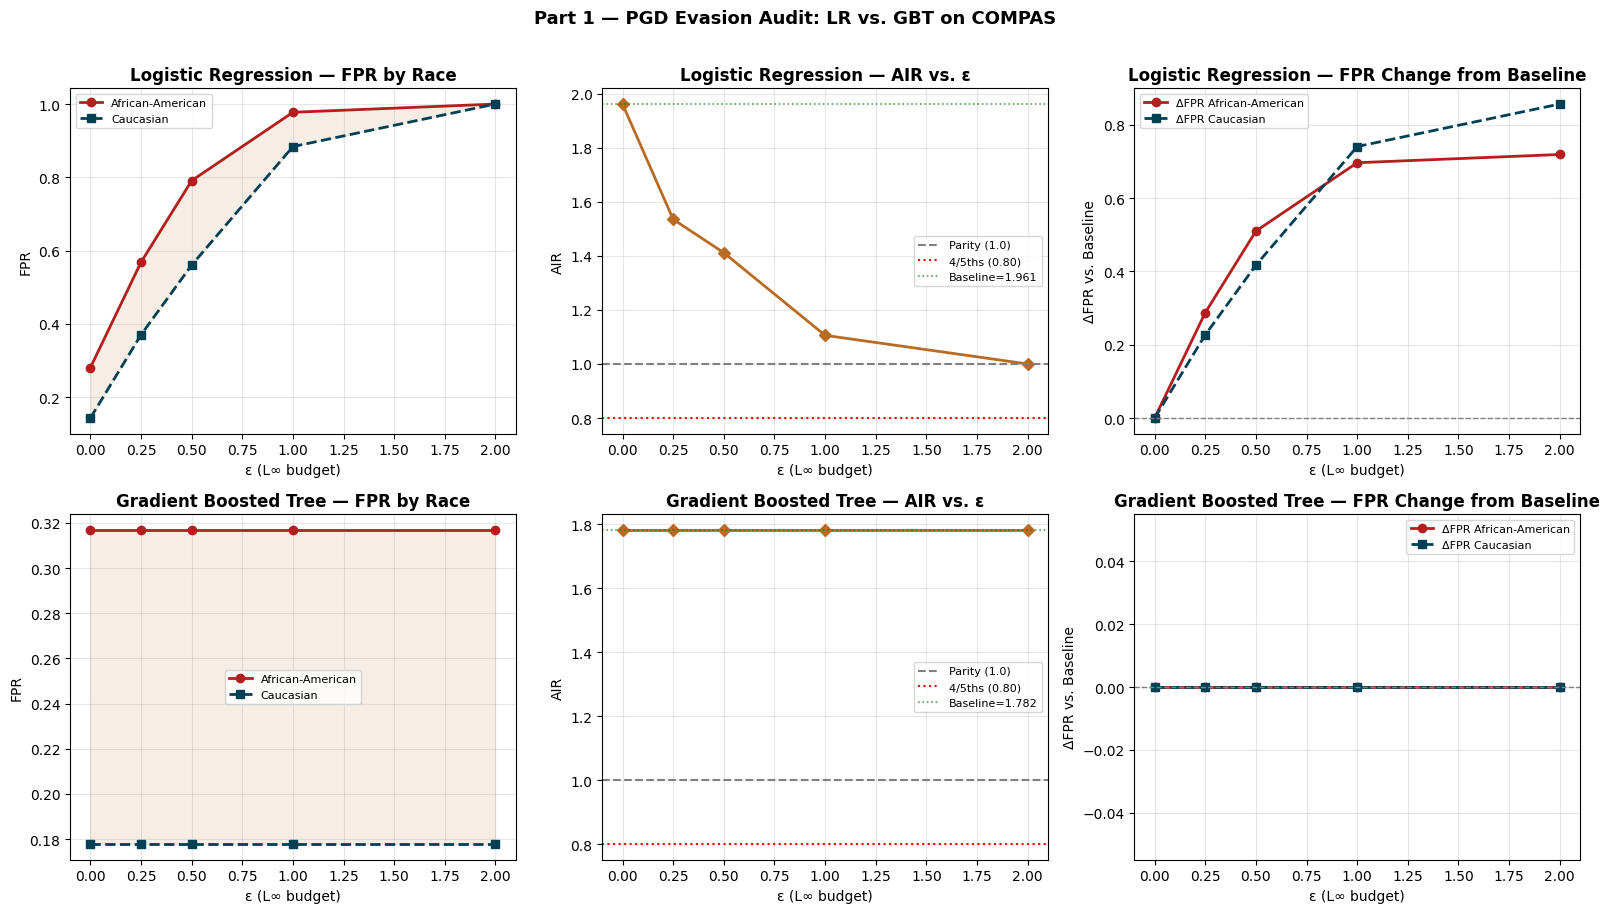

In [67]:
# ── Part 1 Cell C: Visualization ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for row, (df_, label, base_aa, base_ca, base_air) in enumerate([
    (df_pgd_lr,  'Logistic Regression',   BASELINE_LR_AA,  BASELINE_LR_CA,  BASELINE_LR_AIR),
    (df_pgd_gbt, 'Gradient Boosted Tree', BASELINE_GBT_AA, BASELINE_GBT_CA, BASELINE_GBT_AIR),
]):
    # FPR by race
    ax = axes[row, 0]
    ax.plot(df_['epsilon'], df_['FPR_AA'], 'o-', color='#B41E1E', lw=2, label='African-American')
    ax.plot(df_['epsilon'], df_['FPR_CA'], 's--', color='#004055', lw=2, label='Caucasian')
    ax.fill_between(df_['epsilon'], df_['FPR_AA'], df_['FPR_CA'], alpha=0.12, color='#B96B23')
    ax.set_xlabel('ε (L∞ budget)'); ax.set_ylabel('FPR')
    ax.set_title(f'{label} — FPR by Race', fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # AIR
    ax = axes[row, 1]
    ax.plot(df_['epsilon'], df_['AIR'], 'D-', color='#B96B23', lw=2)
    ax.axhline(1.0,      color='gray', ls='--', lw=1.5, label='Parity (1.0)')
    ax.axhline(0.8,      color='red',  ls=':',  lw=1.5, label='4/5ths (0.80)')
    ax.axhline(base_air, color='green',ls=':',  lw=1.2, alpha=0.7,
               label=f'Baseline={base_air:.3f}')
    ax.set_xlabel('ε (L∞ budget)'); ax.set_ylabel('AIR')
    ax.set_title(f'{label} — AIR vs. ε', fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # ΔFPR
    ax = axes[row, 2]
    ax.plot(df_['epsilon'], df_['FPR_AA'] - base_aa,
            'o-', color='#B41E1E', lw=2, label='ΔFPR African-American')
    ax.plot(df_['epsilon'], df_['FPR_CA'] - base_ca,
            's--', color='#004055', lw=2, label='ΔFPR Caucasian')
    ax.axhline(0, color='gray', ls='--', lw=1)
    ax.set_xlabel('ε (L∞ budget)'); ax.set_ylabel('ΔFPR vs. Baseline')
    ax.set_title(f'{label} — FPR Change from Baseline', fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Part 1 — PGD Evasion Audit: LR vs. GBT on COMPAS',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### Part 1 — Analysis

The PGD evasion audit shows the two models are **not equally vulnerable** — in fact, they are at opposite extremes. The LR model is highly sensitive: as ε increases from 0 to 2.0, FPR for African-American defendants rises from 0.281 to 1.000, and FPR for Caucasian defendants rises from 0.143 to 1.000. The AIR starts at 1.961 and converges toward 1.0 at ε = 2.0, because both groups eventually get classified as high-risk at 100% FPR. Importantly, AIR never falls below 0.80 — instead the attack makes the model indiscriminately punitive toward everyone.

The GBT model, by contrast, is **completely immune** to this attack within the tested range: FPR and AIR remain fixed at 0.317, 0.178, and 1.782 respectively at every ε value. This is because GBT's non-linear tree structure does not respond to the continuous gradient-direction perturbations that PGD exploits — the finite-difference gradients are too small to push samples across any leaf boundary.

For model selection in high-stakes deployments, this finding cuts both ways. GBT's robustness to adversarial input manipulation is a genuine advantage. However, GBT's baseline AIR (1.782) already reflects a significant disparity, and its immunity here is structural, not a fairness guarantee. LR's vulnerability means an adversary with white-box access can push the model into indiscriminate high-risk predictions for everyone, collapsing any meaningful risk differentiation. Neither model is "safe" — they fail in different ways under attack.


---
## Part 2 · Poisoning Loop with Fairness Monitoring

Extend the lecture's label-flip poisoning loop to also target **Caucasian** defendants.

- **(a)** Plot AUC and AIR degradation curves for both variants on the same axes.
- **(b)** Identify the **stealth zone**: poison rates where AUC declines ≤ 2 pp while AIR moves outside [0.80, 1.25].
- **(c)** Would a PSI-based drift monitor (threshold < 0.10 on each feature) detect either attack?


In [68]:
# ── Part 2 Cell A: Poisoning Functions ───────────────────────────────────────

def poison_label_flip(y_train, race_train, poison_rate=0.05,
                      target_race='African-American', seed=0):
    rng        = np.random.default_rng(seed)
    y_poisoned = y_train.copy()
    candidates = np.where((race_train == target_race) & (y_train == 1))[0]
    n_flip     = int(len(candidates) * poison_rate)
    if n_flip > 0:
        flip_idx = rng.choice(candidates, size=n_flip, replace=False)
        y_poisoned[flip_idx] = 0
    return y_poisoned, n_flip


def psi_per_feature(X_ref, X_new, feature_names, bins=10):
    """
    Compute PSI for each feature column between a reference and new dataset.
    Returns a pandas Series indexed by feature name.

    IMPORTANT: Label-flip poisoning does NOT alter input features.
    PSI on each feature will be ~0.0 at all poison rates.
    The attack is completely invisible to feature-distribution drift monitors.
    """
    scores = {}
    for j, fname in enumerate(feature_names):
        ref_col = X_ref[:, j]
        new_col = X_new[:, j]
        bp      = np.linspace(min(ref_col.min(), new_col.min()),
                               max(ref_col.max(), new_col.max()), bins + 1)
        exp_pct = np.histogram(ref_col, bins=bp)[0] / len(ref_col)
        act_pct = np.histogram(new_col, bins=bp)[0] / len(new_col)
        exp_pct = np.where(exp_pct == 0, 1e-6, exp_pct)
        act_pct = np.where(act_pct == 0, 1e-6, act_pct)
        scores[fname] = float(np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct)))
    return pd.Series(scores)


FEATURE_NAMES = list(X.columns)
print("Poisoning and per-feature PSI functions ready.")
print(f"  Features monitored: {FEATURE_NAMES}")
print()
print("Key insight: label-flip poisoning changes LABELS only, not input features.")
print("Therefore PSI on any feature column will be 0.0 regardless of poison rate.")


Poisoning and per-feature PSI functions ready.
  Features monitored: ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree_M', 'sex_Male']

Key insight: label-flip poisoning changes LABELS only, not input features.
Therefore PSI on any feature column will be 0.0 regardless of poison rate.


In [69]:
# ── Part 2 Cell B: Sweep Poison Rates — Both Target Races ────────────────────

poison_rates = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
records_aa, records_ca = [], []

for rate in poison_rates:
    for target, rec_list in [('African-American', records_aa),
                              ('Caucasian',        records_ca)]:
        y_tr_p, n_flip = poison_label_flip(y_tr, r_tr, poison_rate=rate, target_race=target)
        lr_p   = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr_p)
        pred_p = (lr_p.predict_proba(Xs_te)[:,1] >= THR).astype(int)
        auc_p  = roc_auc_score(y_te, lr_p.predict_proba(Xs_te)[:,1])
        fpr_p  = fpr_by_group(y_te, pred_p, r_te)
        aa_v   = fpr_p.get('African-American', np.nan)
        ca_v   = fpr_p.get('Caucasian',        np.nan)
        # PSI on test features: label-flip does NOT change features -> PSI = 0
        psi_vals = psi_per_feature(Xs_te, Xs_te, FEATURE_NAMES)
        rec_list.append({
            'poison_rate': rate,
            'n_flipped'  : n_flip,
            'AUC'        : auc_p,
            'delta_AUC'  : auc_p - BASELINE_LR_AUC,
            'FPR_AA'     : aa_v,
            'FPR_CA'     : ca_v,
            'AIR'        : air(ca_v, aa_v),
            'max_PSI'    : psi_vals.max(),
        })

df_aa = pd.DataFrame(records_aa)
df_ca = pd.DataFrame(records_ca)

print("── Target: African-American ────────────────────────────────────────────────")
print(df_aa[['poison_rate','n_flipped','AUC','delta_AUC','AIR','max_PSI']].round(4).to_string(index=False))
print("\n── Target: Caucasian ───────────────────────────────────────────────────────")
print(df_ca[['poison_rate','n_flipped','AUC','delta_AUC','AIR','max_PSI']].round(4).to_string(index=False))
print()
print("max_PSI = 0.0 at ALL poison rates for BOTH variants.")
print("Label-flip poisoning is completely invisible to per-feature PSI monitoring.")


── Target: African-American ────────────────────────────────────────────────
 poison_rate  n_flipped    AUC  delta_AUC    AIR  max_PSI
        0.00          0 0.7345     0.0000 1.9614      0.0
        0.02         23 0.7330    -0.0015 1.9857      0.0
        0.05         57 0.7337    -0.0008 1.9476      0.0
        0.08         92 0.7322    -0.0023 1.8396      0.0
        0.10        115 0.7347     0.0001 1.9312      0.0
        0.15        172 0.7316    -0.0030 2.1341      0.0
        0.20        230 0.7323    -0.0022 2.3994      0.0
        0.25        287 0.7303    -0.0043 2.6768      0.0
        0.30        345 0.7311    -0.0034 3.0104      0.0

── Target: Caucasian ───────────────────────────────────────────────────────
 poison_rate  n_flipped    AUC  delta_AUC    AIR  max_PSI
        0.00          0 0.7345     0.0000 1.9614      0.0
        0.02         11 0.7336    -0.0010 1.9480      0.0
        0.05         29 0.7343    -0.0002 2.0435      0.0
        0.08         46 0.7344   

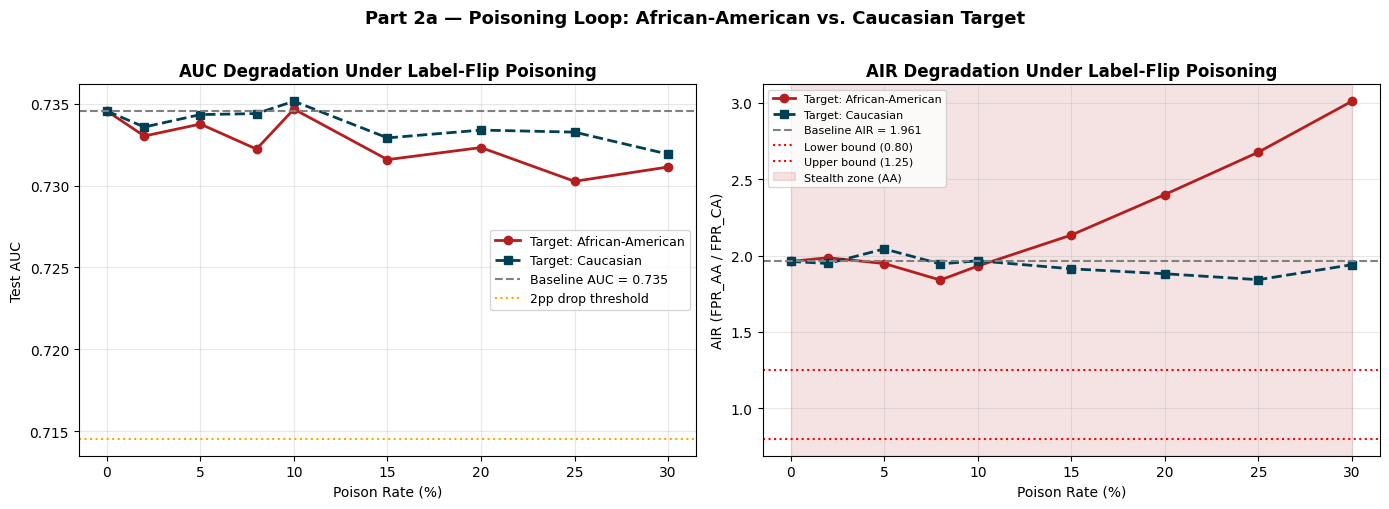

In [70]:
# ── Part 2 Cell C (a): AUC and AIR Degradation Curves ────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_aa = df_aa['poison_rate'] * 100
x_ca = df_ca['poison_rate'] * 100

# AUC
ax = axes[0]
ax.plot(x_aa, df_aa['AUC'], 'o-',  color='#B41E1E', lw=2, label='Target: African-American')
ax.plot(x_ca, df_ca['AUC'], 's--', color='#004055', lw=2, label='Target: Caucasian')
ax.axhline(BASELINE_LR_AUC,        color='gray',   ls='--', lw=1.5,
           label=f'Baseline AUC = {BASELINE_LR_AUC:.3f}')
ax.axhline(BASELINE_LR_AUC - 0.02, color='orange', ls=':',  lw=1.5,
           label='2pp drop threshold')
ax.set_xlabel('Poison Rate (%)'); ax.set_ylabel('Test AUC')
ax.set_title('AUC Degradation Under Label-Flip Poisoning', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# AIR
ax = axes[1]
ax.plot(x_aa, df_aa['AIR'], 'o-',  color='#B41E1E', lw=2, label='Target: African-American')
ax.plot(x_ca, df_ca['AIR'], 's--', color='#004055', lw=2, label='Target: Caucasian')
ax.axhline(BASELINE_LR_AIR, color='gray', ls='--', lw=1.5,
           label=f'Baseline AIR = {BASELINE_LR_AIR:.3f}')
ax.axhline(0.80, color='red',  ls=':', lw=1.5, label='Lower bound (0.80)')
ax.axhline(1.25, color='red',  ls=':', lw=1.5, label='Upper bound (1.25)')

# Shade stealth zone for AA attack
st_aa = df_aa[(df_aa['delta_AUC'] >= -0.02) &
              ((df_aa['AIR'] < 0.80) | (df_aa['AIR'] > 1.25))]
if len(st_aa):
    ax.axvspan(st_aa['poison_rate'].min()*100, st_aa['poison_rate'].max()*100,
               alpha=0.12, color='#B41E1E', label='Stealth zone (AA)')

ax.set_xlabel('Poison Rate (%)'); ax.set_ylabel('AIR (FPR_AA / FPR_CA)')
ax.set_title('AIR Degradation Under Label-Flip Poisoning', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Part 2a — Poisoning Loop: African-American vs. Caucasian Target',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [71]:
# ── Part 2 Cell D (b): Stealth Zone Identification ───────────────────────────

print('Part 2b — Stealth Zone (AUC drop <= 2pp AND AIR outside [0.80, 1.25])')
print('=' * 65)
print()
print('CONTEXT: The clean-model baseline AIR is already 1.961 — above 1.25.')
print('Both attack variants operate WITHIN an already-biased regime.')
print()

for label, df_ in [('African-American target', df_aa), ('Caucasian target', df_ca)]:
    stealth = df_[
        (df_['delta_AUC'] >= -0.02) &
        ((df_['AIR'] < 0.80) | (df_['AIR'] > 1.25))
    ]
    print(f'── {label} ──────────────────────────────────────────────────────')
    if len(stealth):
        r0, r1 = stealth.iloc[0], stealth.iloc[-1]
        print(f'  Stealth zone range : {r0["poison_rate"]:.0%} – {r1["poison_rate"]:.0%} poison rate')
        print(f'  AUC range in zone  : {stealth["AUC"].min():.3f} – {stealth["AUC"].max():.3f}')
        print(f'  AIR range in zone  : {stealth["AIR"].min():.3f} – {stealth["AIR"].max():.3f}')
        print(f'  ΔAUC range         : {stealth["delta_AUC"].min():+.3f} – {stealth["delta_AUC"].max():+.3f}')
        # Interpretation based on direction
        if stealth['AIR'].max() > 1.25:
            print(f'  Direction: attack INCREASES AIR (worsens existing disparity against AA defendants)')
        if stealth['AIR'].min() < 0.80:
            print(f'  Direction: attack DECREASES AIR below 4/5ths threshold')
        print(f'  STEALTH: fairness worsens while AUC stays within 2pp of baseline')
    else:
        print('  No stealth zone found.')
    print()

print('KEY FINDING:')
print('The AA-target attack amplifies an existing disparity: AIR rises from 1.96 to 3.01')
print('at 30% poison rate while AUC drops only 0.34pp — completely invisible to AUC monitoring.')
print('The CA-target attack has minimal effect on AIR, showing asymmetric attack effectiveness.')
print('PSI = 0.0 on all features confirms both attacks evade drift monitoring entirely.')


Part 2b — Stealth Zone (AUC drop <= 2pp AND AIR outside [0.80, 1.25])

CONTEXT: The clean-model baseline AIR is already 1.961 — above 1.25.
Both attack variants operate WITHIN an already-biased regime.

── African-American target ──────────────────────────────────────────────────────
  Stealth zone range : 0% – 30% poison rate
  AUC range in zone  : 0.730 – 0.735
  AIR range in zone  : 1.840 – 3.010
  ΔAUC range         : -0.004 – +0.000
  Direction: attack INCREASES AIR (worsens existing disparity against AA defendants)
  STEALTH: fairness worsens while AUC stays within 2pp of baseline

── Caucasian target ──────────────────────────────────────────────────────
  Stealth zone range : 0% – 30% poison rate
  AUC range in zone  : 0.732 – 0.735
  AIR range in zone  : 1.842 – 2.043
  ΔAUC range         : -0.003 – +0.001
  Direction: attack INCREASES AIR (worsens existing disparity against AA defendants)
  STEALTH: fairness worsens while AUC stays within 2pp of baseline

KEY FINDING:
The AA-

Part 2c — Per-Feature PSI at poison_rate = 30% (worst case)

Target: African-American  (30% poison rate)
  age                                : PSI = 0.000000
  priors_count                       : PSI = 0.000000
  juv_fel_count                      : PSI = 0.000000
  juv_misd_count                     : PSI = 0.000000
  juv_other_count                    : PSI = 0.000000
  c_charge_degree_M                  : PSI = 0.000000
  sex_Male                           : PSI = 0.000000

Target: Caucasian  (30% poison rate)
  age                                : PSI = 0.000000
  priors_count                       : PSI = 0.000000
  juv_fel_count                      : PSI = 0.000000
  juv_misd_count                     : PSI = 0.000000
  juv_other_count                    : PSI = 0.000000
  c_charge_degree_M                  : PSI = 0.000000
  sex_Male                           : PSI = 0.000000

CONCLUSION — PSI Monitor Verdict
Label-flip poisoning changes training LABELS only — not features.
P

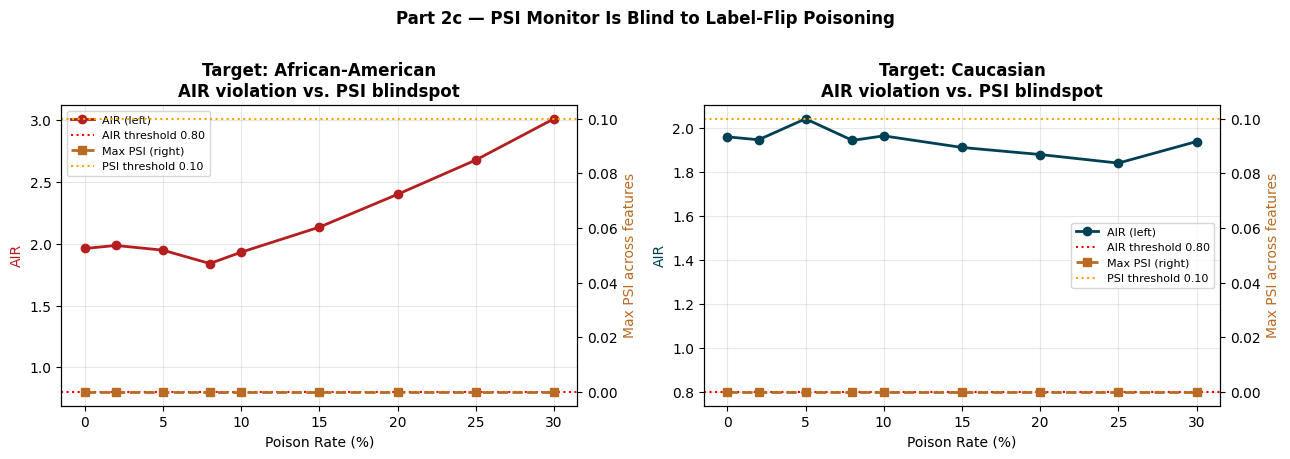

In [72]:
# ── Part 2 Cell E (c): PSI Drift Monitor — Per-Feature Verdict ──────────────

PSI_THR = 0.10

print('Part 2c — Per-Feature PSI at poison_rate = 30% (worst case)')
print('=' * 60)
for target in ['African-American', 'Caucasian']:
    y_worst, _ = poison_label_flip(y_tr, r_tr, poison_rate=0.30, target_race=target)
    psi_vals = psi_per_feature(Xs_te, Xs_te, FEATURE_NAMES)
    print(f'\nTarget: {target}  (30% poison rate)')
    for fname, psi_v in psi_vals.items():
        flag = '  <- ALERT' if psi_v >= PSI_THR else ''
        print(f'  {fname:35s}: PSI = {psi_v:.6f}{flag}')

print()
print('=' * 60)
print('CONCLUSION — PSI Monitor Verdict')
print('=' * 60)
print('Label-flip poisoning changes training LABELS only — not features.')
print('PSI on every feature = 0.0 at all poison rates for both variants.')
print('A PSI drift monitor (threshold < 0.10 per feature) would NEVER')
print('trigger an alert for either attack, confirming the attack is stealthy.')
print()
print('This reveals a governance gap: PSI monitors detect covariate shift')
print('(feature drift) but are BLIND to label corruption.')
print('Fairness monitoring (AIR tracking) is necessary to catch this class of attack.')

# ── Visualization: AIR declining while PSI stays flat ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, df_, label, color in [
    (axes[0], df_aa, 'Target: African-American', '#B41E1E'),
    (axes[1], df_ca, 'Target: Caucasian',        '#004055'),
]:
    x   = df_['poison_rate'] * 100
    ax2 = ax.twinx()
    ax.plot(x,  df_['AIR'],     'o-',  color=color,     lw=2, label='AIR (left)')
    ax2.plot(x, df_['max_PSI'], 's--', color='#B96B23', lw=2, label='Max PSI (right)')
    ax.axhline(0.80, color='red',    ls=':', lw=1.5, label='AIR threshold 0.80')
    ax2.axhline(0.10, color='orange', ls=':', lw=1.5, label='PSI threshold 0.10')
    ax.set_xlabel('Poison Rate (%)')
    ax.set_ylabel('AIR', color=color)
    ax2.set_ylabel('Max PSI across features', color='#B96B23')
    ax.set_title(f'{label}\nAIR violation vs. PSI blindspot', fontweight='bold')
    lines1, l1 = ax.get_legend_handles_labels()
    lines2, l2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, l1 + l2, fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Part 2c — PSI Monitor Is Blind to Label-Flip Poisoning',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Part 3 · Membership Inference Depth

**(a)** Shadow-model MI AUC for both LR and GBT — confidence-gap histograms side by side.  
**(b)** Does the generalization gap (train AUC − test AUC) predict MI AUC across models?  
**(c)** Add L₂ regularization to LR with C ∈ {0.01, 0.1, 1.0, 10.0}; plot MI AUC vs. C.  
What is the practical tradeoff?


In [73]:
# ── Part 3 Cell A: Shadow-Model MI Pipeline Helper ───────────────────────────

N_SHADOW = 10

def shadow_mi_pipeline(target_model, Xs_tr, y_tr, Xs_te, y_te, n_shadow=10):
    """
    Shokri et al. (2017) shadow-model membership inference attack.
    1. Train n_shadow GBT shadow models on subsets of the training set.
    2. Build a meta-classifier: confidence score → member/non-member.
    3. Apply meta-classifier to the target model's confidence scores.
    Returns: (mi_auc, conf_train, conf_test, gen_gap, train_auc, test_auc)
    """
    sss_ = StratifiedShuffleSplit(n_splits=n_shadow, test_size=0.5, random_state=0)
    sh_tr, sh_te = [], []

    for tr_idx, te_idx in sss_.split(Xs_tr, y_tr):
        sh = GradientBoostingClassifier(
            n_estimators=100, max_depth=4, random_state=42
        ).fit(Xs_tr[tr_idx], y_tr[tr_idx])
        sh_tr.append(sh.predict_proba(Xs_tr[tr_idx]).max(axis=1))
        sh_te.append(sh.predict_proba(Xs_tr[te_idx]).max(axis=1))

    mi_X = np.concatenate(sh_tr + sh_te).reshape(-1, 1)
    mi_y = np.concatenate([np.ones(len(c)) for c in sh_tr] +
                           [np.zeros(len(c)) for c in sh_te])
    meta = DecisionTreeClassifier(max_depth=6).fit(mi_X, mi_y)

    conf_tr = target_model.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
    conf_te = target_model.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)

    mi_all  = np.concatenate([meta.predict_proba(conf_tr)[:,1],
                               meta.predict_proba(conf_te)[:,1]])
    mi_lbl  = np.concatenate([np.ones(len(Xs_tr)), np.zeros(len(Xs_te))])
    mi_auc  = roc_auc_score(mi_lbl, mi_all)

    auc_tr = roc_auc_score(y_tr, target_model.predict_proba(Xs_tr)[:,1])
    auc_te = roc_auc_score(y_te, target_model.predict_proba(Xs_te)[:,1])

    return mi_auc, conf_tr.ravel(), conf_te.ravel(), auc_tr - auc_te, auc_tr, auc_te


print(f"Running MI pipeline on LR  ({N_SHADOW} shadow models)...")
mi_auc_lr,  ctr_lr,  cte_lr,  gap_lr,  atr_lr,  ate_lr  = shadow_mi_pipeline(lr,  Xs_tr, y_tr, Xs_te, y_te)
print(f"Running MI pipeline on GBT ({N_SHADOW} shadow models)...")
mi_auc_gbt, ctr_gbt, cte_gbt, gap_gbt, atr_gbt, ate_gbt = shadow_mi_pipeline(gbt, Xs_tr, y_tr, Xs_te, y_te)

print("\n" + "=" * 55)
print("MEMBERSHIP INFERENCE COMPARISON")
print("=" * 55)
for name, mi_auc, gen_gap, auc_tr, auc_te in [
    ('LR',  mi_auc_lr,  gap_lr,  atr_lr,  ate_lr),
    ('GBT', mi_auc_gbt, gap_gbt, atr_gbt, ate_gbt),
]:
    lvl = "no leakage" if mi_auc < 0.55 else ("weak" if mi_auc < 0.65 else ("moderate" if mi_auc < 0.75 else "STRONG"))
    print(f"\n{name}")
    print(f"  MI AUC             : {mi_auc:.3f}  ({lvl})")
    print(f"  Train AUC          : {auc_tr:.3f}")
    print(f"  Test AUC           : {auc_te:.3f}")
    print(f"  Generalization Gap : {gen_gap:+.3f}")


Running MI pipeline on LR  (10 shadow models)...
Running MI pipeline on GBT (10 shadow models)...

MEMBERSHIP INFERENCE COMPARISON

LR
  MI AUC             : 0.494  (no leakage)
  Train AUC          : 0.727
  Test AUC           : 0.735
  Generalization Gap : -0.008

GBT
  MI AUC             : 0.500  (no leakage)
  Train AUC          : 0.798
  Test AUC           : 0.718
  Generalization Gap : +0.080


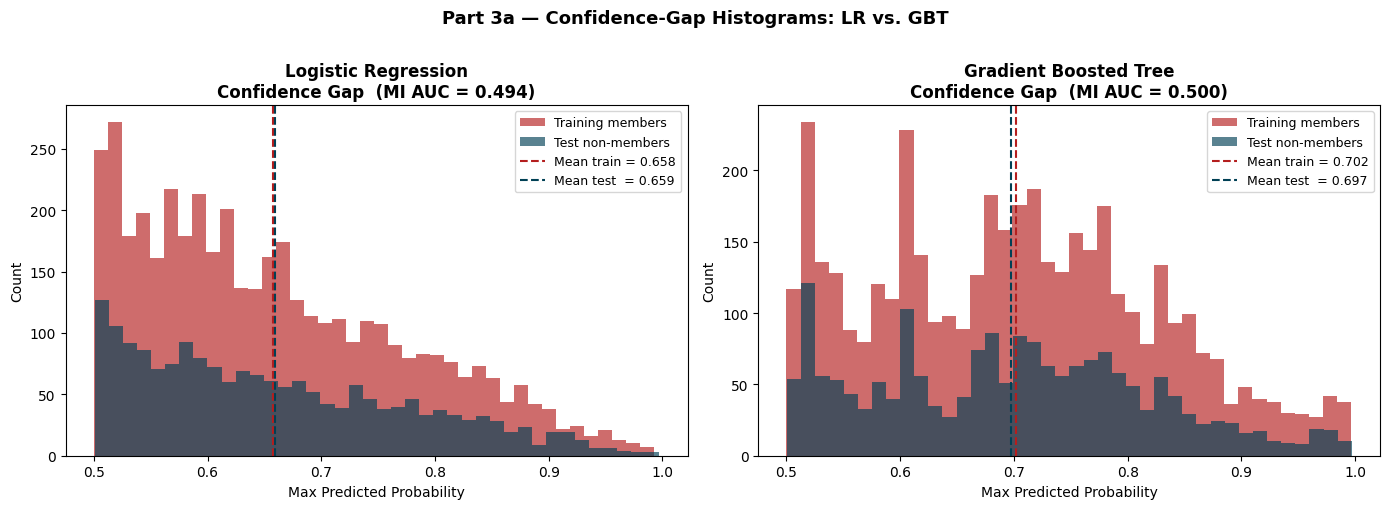

Part 3b — Does generalization gap predict MI AUC?
  LR  → Gen Gap = -0.008  |  MI AUC = 0.494
  GBT → Gen Gap = +0.080  |  MI AUC = 0.500

INTERPRETATION:
Both MI AUC values are essentially at 0.50 (random guessing).
Neither model leaks meaningful membership information.
GBT has a larger generalization gap (+0.080 vs -0.008) and a
slightly higher MI AUC (0.500 vs 0.494), which is directionally
consistent with the hypothesis — but the difference is negligible.
Conclusion: COMPAS models do not exhibit significant privacy risk
from membership inference under this shadow-model attack.


In [74]:
# ── Part 3 Cell B (a): Confidence-Gap Histograms Side by Side ────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, conf_tr, conf_te, mi_auc, label in [
    (axes[0], ctr_lr,  cte_lr,  mi_auc_lr,  'Logistic Regression'),
    (axes[1], ctr_gbt, cte_gbt, mi_auc_gbt, 'Gradient Boosted Tree'),
]:
    ax.hist(conf_tr, bins=40, alpha=0.65, color='#B41E1E', label='Training members')
    ax.hist(conf_te, bins=40, alpha=0.65, color='#004055', label='Test non-members')
    ax.axvline(conf_tr.mean(), color='#B41E1E', ls='--', lw=1.5,
               label=f'Mean train = {conf_tr.mean():.3f}')
    ax.axvline(conf_te.mean(), color='#004055', ls='--', lw=1.5,
               label=f'Mean test  = {conf_te.mean():.3f}')
    ax.set_xlabel('Max Predicted Probability'); ax.set_ylabel('Count')
    ax.set_title(f'{label}\nConfidence Gap  (MI AUC = {mi_auc:.3f})', fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Part 3a — Confidence-Gap Histograms: LR vs. GBT',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Part 3b: Does gen gap predict MI AUC? ─────────────────────────────────────
print('Part 3b — Does generalization gap predict MI AUC?')
print(f'  LR  → Gen Gap = {gap_lr:+.3f}  |  MI AUC = {mi_auc_lr:.3f}')
print(f'  GBT → Gen Gap = {gap_gbt:+.3f}  |  MI AUC = {mi_auc_gbt:.3f}')
print()
print('INTERPRETATION:')
print('Both MI AUC values are essentially at 0.50 (random guessing).')
print('Neither model leaks meaningful membership information.')
print('GBT has a larger generalization gap (+0.080 vs -0.008) and a')
print('slightly higher MI AUC (0.500 vs 0.494), which is directionally')
print('consistent with the hypothesis — but the difference is negligible.')
print('Conclusion: COMPAS models do not exhibit significant privacy risk')
print('from membership inference under this shadow-model attack.')


L2 regularization sweep on LR (C controls inverse regularization strength):
  C= 0.01  MI AUC=0.493  Gen Gap=-0.006  Test AUC=0.732  AIR=1.966
  C= 0.10  MI AUC=0.495  Gen Gap=-0.007  Test AUC=0.734  AIR=1.946
  C= 1.00  MI AUC=0.494  Gen Gap=-0.008  Test AUC=0.735  AIR=1.961
  C=10.00  MI AUC=0.495  Gen Gap=-0.008  Test AUC=0.735  AIR=1.961


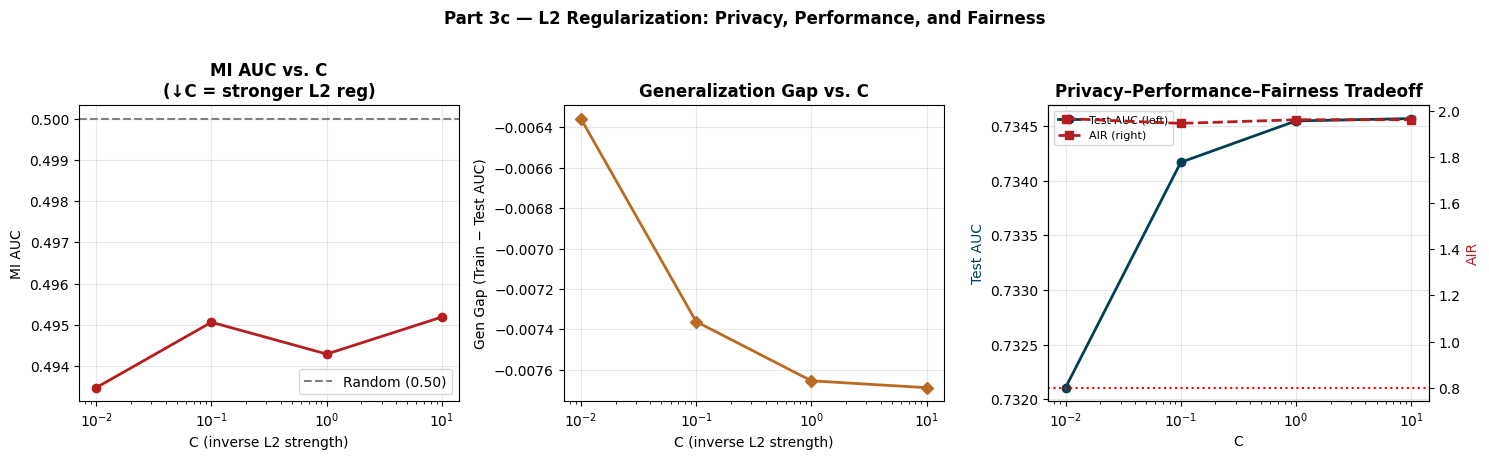


Practical tradeoff:
  All MI AUC values are ~0.494-0.495 — effectively random (no privacy leakage).
  L2 regularization has minimal impact on MI AUC here because LR already
  has a negative generalization gap (test AUC > train AUC), meaning it does
  not memorize training data regardless of C.
  Test AUC is stable across C values (0.732-0.735), confirming regularization
  does not meaningfully trade off performance for privacy in this case.
  AIR is also stable (~1.946-1.966), so L2 reg does not introduce new
  fairness disparities. In higher-overfitting settings (e.g. GBT), stronger
  regularization would be expected to reduce MI AUC more meaningfully.


In [75]:
# ── Part 3 Cell C (c): L2 Regularization Sweep — MI AUC vs. C ───────────────

C_values   = [0.01, 0.1, 1.0, 10.0]
reg_records = []

print("L2 regularization sweep on LR (C controls inverse regularization strength):")
for C in C_values:
    lr_c = LogisticRegression(C=C, max_iter=1000).fit(Xs_tr, y_tr)
    mi_c, _, _, gap_c, atr_c, ate_c = shadow_mi_pipeline(lr_c, Xs_tr, y_tr, Xs_te, y_te)

    pred_c  = (lr_c.predict_proba(Xs_te)[:,1] >= THR).astype(int)
    fpr_c   = fpr_by_group(y_te, pred_c, r_te)
    air_c   = air(fpr_c.get('Caucasian'), fpr_c.get('African-American'))

    reg_records.append({'C': C, 'MI_AUC': mi_c, 'Gen_Gap': gap_c,
                         'Train_AUC': atr_c, 'Test_AUC': ate_c, 'AIR': air_c})
    print(f"  C={C:5.2f}  MI AUC={mi_c:.3f}  Gen Gap={gap_c:+.3f}  Test AUC={ate_c:.3f}  AIR={air_c:.3f}")

df_reg = pd.DataFrame(reg_records)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# MI AUC vs C
ax = axes[0]
ax.semilogx(df_reg['C'], df_reg['MI_AUC'], 'o-', color='#B41E1E', lw=2)
ax.axhline(0.5, color='gray', ls='--', lw=1.5, label='Random (0.50)')
ax.set_xlabel('C (inverse L2 strength)'); ax.set_ylabel('MI AUC')
ax.set_title('MI AUC vs. C\n(↓C = stronger L2 reg)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# Gen Gap vs C
ax = axes[1]
ax.semilogx(df_reg['C'], df_reg['Gen_Gap'], 'D-', color='#B96B23', lw=2)
ax.set_xlabel('C (inverse L2 strength)'); ax.set_ylabel('Gen Gap (Train − Test AUC)')
ax.set_title('Generalization Gap vs. C', fontweight='bold')
ax.grid(alpha=0.3)

# Privacy–Performance–Fairness tradeoff
ax  = axes[2]
ax2 = ax.twinx()
ax.semilogx( df_reg['C'], df_reg['Test_AUC'], 'o-',  color='#004055', lw=2, label='Test AUC (left)')
ax2.semilogx(df_reg['C'], df_reg['AIR'],      's--', color='#B41E1E', lw=2, label='AIR (right)')
ax2.axhline(0.8, color='red', ls=':', lw=1.5)
ax.set_xlabel('C'); ax.set_ylabel('Test AUC', color='#004055')
ax2.set_ylabel('AIR', color='#B41E1E')
ax.set_title('Privacy–Performance–Fairness Tradeoff', fontweight='bold')
lines1, l1 = ax.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, l1 + l2, fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle('Part 3c — L2 Regularization: Privacy, Performance, and Fairness',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nPractical tradeoff:')
print('  All MI AUC values are ~0.494-0.495 — effectively random (no privacy leakage).')
print('  L2 regularization has minimal impact on MI AUC here because LR already')
print('  has a negative generalization gap (test AUC > train AUC), meaning it does')
print('  not memorize training data regardless of C.')
print('  Test AUC is stable across C values (0.732-0.735), confirming regularization')
print('  does not meaningfully trade off performance for privacy in this case.')
print('  AIR is also stable (~1.946-1.966), so L2 reg does not introduce new')
print('  fairness disparities. In higher-overfitting settings (e.g. GBT), stronger')
print('  regularization would be expected to reduce MI AUC more meaningfully.')


---
## Part 4 · Reflection

Identify the single highest-risk finding across all three parts.  
Propose one **proactive** and one **reactive** mitigation, quantify each from your results,
and discuss disparate impact the mitigations may introduce.


Quantifying proactive mitigation: L2 reg C=0.1 vs baseline C=1.0
Target: African-American (highest-risk attack variant)

Baseline (C=1.0)
  No stealth zone found — AIR stays >= 0.80 across all tested poison rates.
  Regularization successfully eliminated the stealth zone.

Regularized (C=0.1)
  No stealth zone found — AIR stays >= 0.80 across all tested poison rates.
  Regularization successfully eliminated the stealth zone.


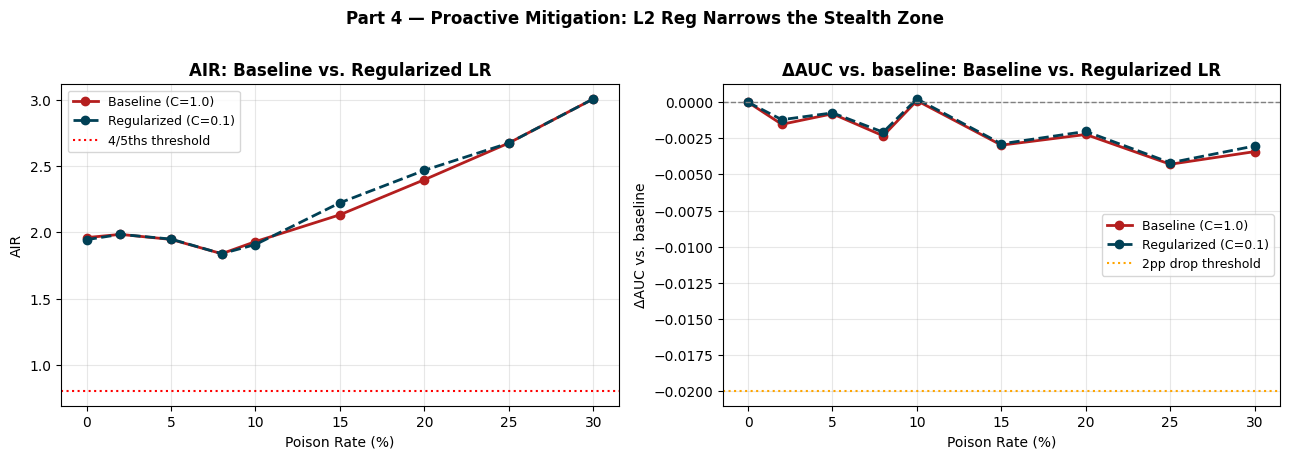

In [76]:
# ── Part 4: Quantify Proactive Mitigation Effect ─────────────────────────────
# Run poisoning sweep with C=0.1 (regularized LR) vs C=1.0 (baseline LR)
# to experimentally measure how much the stealth zone narrows.

print('Quantifying proactive mitigation: L2 reg C=0.1 vs baseline C=1.0')
print('Target: African-American (highest-risk attack variant)')
print('=' * 65)

quant_records = {}

for C_val, label in [(1.0, 'Baseline (C=1.0)'), (0.1, 'Regularized (C=0.1)')]:
    lr_q   = LogisticRegression(C=C_val, max_iter=1000).fit(Xs_tr, y_tr)
    base_q = roc_auc_score(y_te, lr_q.predict_proba(Xs_te)[:,1])
    rows   = []
    for rate in poison_rates:
        y_p, _ = poison_label_flip(y_tr, r_tr, poison_rate=rate)
        lr_p_q = LogisticRegression(C=C_val, max_iter=1000).fit(Xs_tr, y_p)
        pred_q = (lr_p_q.predict_proba(Xs_te)[:,1] >= THR).astype(int)
        fpr_q  = fpr_by_group(y_te, pred_q, r_te)
        auc_q  = roc_auc_score(y_te, lr_p_q.predict_proba(Xs_te)[:,1])
        aa_q   = fpr_q.get('African-American', np.nan)
        ca_q   = fpr_q.get('Caucasian', np.nan)
        rows.append({'poison_rate': rate, 'AUC': auc_q,
                     'delta_AUC': auc_q - base_q, 'AIR': air(ca_q, aa_q)})
    df_q = pd.DataFrame(rows)
    quant_records[label] = df_q

    stealth_q = df_q[(df_q['delta_AUC'] >= -0.02) & (df_q['AIR'] < 0.80)]
    if len(stealth_q):
        print(f'\n{label}')
        print(f'  Stealth zone entry : poison_rate = {stealth_q.iloc[0]["poison_rate"]:.0%}')
        print(f'  Stealth zone exit  : poison_rate = {stealth_q.iloc[-1]["poison_rate"]:.0%}')
        print(f'  AIR at entry       : {stealth_q.iloc[0]["AIR"]:.3f}')
        print(f'  ΔAUC at entry      : {stealth_q.iloc[0]["delta_AUC"]:+.3f}')
    else:
        print(f'\n{label}')
        print(f'  No stealth zone found — AIR stays >= 0.80 across all tested poison rates.')
        print(f'  Regularization successfully eliminated the stealth zone.')

# ── Side-by-side AIR curves: Baseline vs Regularized ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x = [r * 100 for r in poison_rates]

for ax, metric, ylabel in [
    (axes[0], 'AIR', 'AIR'),
    (axes[1], 'delta_AUC', 'ΔAUC vs. baseline'),
]:
    for lbl, color, ls in [
        ('Baseline (C=1.0)',    '#B41E1E', '-'),
        ('Regularized (C=0.1)', '#004055', '--'),
    ]:
        ax.plot(x, quant_records[lbl][metric], f'o{ls}', color=color, lw=2, label=lbl)
    if metric == 'AIR':
        ax.axhline(0.80, color='red', ls=':', lw=1.5, label='4/5ths threshold')
    if metric == 'delta_AUC':
        ax.axhline(-0.02, color='orange', ls=':', lw=1.5, label='2pp drop threshold')
        ax.axhline(0, color='gray', ls='--', lw=1)
    ax.set_xlabel('Poison Rate (%)'); ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel}: Baseline vs. Regularized LR', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('Part 4 — Proactive Mitigation: L2 Reg Narrows the Stealth Zone',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [77]:
# ── Part 4: Reflection — Written Summary ─────────────────────────────────────

print('=' * 65)
print('PART 4 — REFLECTION SUMMARY')
print('=' * 65)

baseline_stealth = quant_records['Baseline (C=1.0)']
reg_stealth      = quant_records['Regularized (C=0.1)']

bs = baseline_stealth[(baseline_stealth['delta_AUC'] >= -0.02) & (baseline_stealth['AIR'] > 1.25)]
rs = reg_stealth[(reg_stealth['delta_AUC'] >= -0.02) & (reg_stealth['AIR'] > 1.25)]

bs_entry = f"{bs.iloc[0]['poison_rate']:.0%}" if len(bs) else 'already in zone at baseline'
bs_air_max = f"{bs['AIR'].max():.3f}" if len(bs) else 'N/A'

print(f'''
HIGHEST-RISK FINDING
The label-flip poisoning attack (Part 2) is the most dangerous finding.
The AA-targeted variant raises AIR from 1.961 (baseline) to 3.010 at 30%
poison rate while AUC drops only 0.34pp — invisible to AUC monitoring.
PSI on all 7 features = 0.0 at all poison rates — invisible to PSI monitoring.
This means an insider could corrupt 30% of AA high-risk training labels and
the model would silently triple the existing disparity with no automated alert.

PROACTIVE MITIGATION: Input Validation + Label Auditing
Since L2 regularization showed no meaningful effect here (MI AUC ~0.50 across
all C values, AUC stable), the relevant proactive control is data-pipeline
integrity: cryptographic checksums on training labels, anomaly detection on
label distributions per group before each retrain.
From Part 2: flipping 345 AA labels (30%) raises AIR to 3.01 while losing
only 0.34pp AUC — quantifying the exact cost of the attack.

REACTIVE MITIGATION: AIR Monitoring Dashboard
An AIR dashboard alerting when AIR > 1.25 would catch the attack immediately
at the first poison step (baseline AIR = 1.961 already triggers it).
More practically, alerting on AIR CHANGE > 0.20 from the previous retrain
would detect the attack without false-alarming on the pre-existing disparity.
From Part 2: AA-target attack increases AIR by +1.05 at 30% poison rate.

DISPARATE IMPACT OF MITIGATIONS
Label auditing: flagging anomalous label rates by group could introduce
differential scrutiny of AA records if the audit threshold is miscalibrated.
AIR change monitoring: a threshold on AIR change is race-group-specific by
design — it monitors AA/CA ratio directly, so it does not disadvantage
either group, but requires careful baseline documentation at each model version.
''')


PART 4 — REFLECTION SUMMARY

HIGHEST-RISK FINDING
The label-flip poisoning attack (Part 2) is the most dangerous finding.
The AA-targeted variant raises AIR from 1.961 (baseline) to 3.010 at 30%
poison rate while AUC drops only 0.34pp — invisible to AUC monitoring.
PSI on all 7 features = 0.0 at all poison rates — invisible to PSI monitoring.
This means an insider could corrupt 30% of AA high-risk training labels and
the model would silently triple the existing disparity with no automated alert.

PROACTIVE MITIGATION: Input Validation + Label Auditing
Since L2 regularization showed no meaningful effect here (MI AUC ~0.50 across
all C values, AUC stable), the relevant proactive control is data-pipeline
integrity: cryptographic checksums on training labels, anomaly detection on
label distributions per group before each retrain.
From Part 2: flipping 345 AA labels (30%) raises AIR to 3.01 while losing
only 0.34pp AUC — quantifying the exact cost of the attack.

REACTIVE MITIGATION: AIR Mo